# Lending Club - Risk Model

## Project Overview
This notebook covers data preparation for the LendingClub Probability of Default (PD) model.

**Steps covered:**
1. Data loading and exploration
2. Type conversions (term, employment length, dates)
3. Dummy variable creation
4. Missing value imputation
5. Target variable definition (good vs bad loan)
6. Train/test split
7. Weight of Evidence (WoE) encoding for all features
8. Export of processed datasets

# Import Libraries

In [35]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Import Dataset

In [37]:
df_lc = pd.read_csv("data/lendingclub.csv", low_memory=False)

In [38]:
df_lc.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Dataset Exploration

In [40]:
df_lc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

# Switching variable "Term" to numeric

In [42]:
df_lc['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [43]:
df_lc['term_num'] = df_lc['term'].str.replace(' months','')

In [44]:
df_lc['term_num'].unique()

array([' 36', ' 60'], dtype=object)

In [45]:
df_lc['term_num'] = pd.to_numeric(df_lc['term_num'])

In [46]:
df_lc['term_num'].unique()

array([36, 60], dtype=int64)

# Switching emp_length (employment length) to numeric

In [48]:
df_lc['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

In [49]:
df_lc['emp_length_num'] = df_lc['emp_length'].str.replace('+ years','')
df_lc['emp_length_num'] = df_lc['emp_length_num'].str.replace('< 1 year',str(0))
df_lc['emp_length_num'] = df_lc['emp_length_num'].str.replace('years','')
df_lc['emp_length_num'] = df_lc['emp_length_num'].str.replace('year','')
df_lc['emp_length_num'] = df_lc['emp_length_num'].replace(np.nan,str(0))


In [50]:
df_lc['emp_length_num'].unique()

array(['10', '0', '1 ', '3 ', '8 ', '9 ', '4 ', '5 ', '6 ', '2 ', '7 '],
      dtype=object)

In [51]:
df_lc['emp_length_num'] = pd.to_numeric(df_lc['emp_length_num'])

In [52]:
df_lc['emp_length_num'].unique()

array([10,  0,  1,  3,  8,  9,  4,  5,  6,  2,  7], dtype=int64)

# Switching "issue_d" (issue date) to date

In [54]:
df_lc['issue_d']

0         Dec-11
1         Dec-11
2         Dec-11
3         Dec-11
4         Dec-11
           ...  
466280    Jan-14
466281    Jan-14
466282    Jan-14
466283    Jan-14
466284    Jan-14
Name: issue_d, Length: 466285, dtype: object

In [55]:
df_lc['issue_date'] = pd.to_datetime(df_lc['issue_d'], format = '%b-%y')

In [56]:
df_lc['issue_date']

0        2011-12-01
1        2011-12-01
2        2011-12-01
3        2011-12-01
4        2011-12-01
            ...    
466280   2014-01-01
466281   2014-01-01
466282   2014-01-01
466283   2014-01-01
466284   2014-01-01
Name: issue_date, Length: 466285, dtype: datetime64[ns]

In [57]:
df_lc["issue_date"] = pd.to_datetime(df_lc["issue_date"], errors="coerce")

ref = pd.Timestamp("2022-01-01")

df_lc["credit_months"] = (
    (ref.year - df_lc["issue_date"].dt.year) * 12
    + (ref.month - df_lc["issue_date"].dt.month)
)


In [58]:
df_lc["credit_months"]

0         121
1         121
2         121
3         121
4         121
         ... 
466280     96
466281     96
466282     96
466283     96
466284     96
Name: credit_months, Length: 466285, dtype: int32

# Creating Dummy Variables

In [60]:
df_lc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Unnamed: 0                   466285 non-null  int64         
 1   id                           466285 non-null  int64         
 2   member_id                    466285 non-null  int64         
 3   loan_amnt                    466285 non-null  int64         
 4   funded_amnt                  466285 non-null  int64         
 5   funded_amnt_inv              466285 non-null  float64       
 6   term                         466285 non-null  object        
 7   int_rate                     466285 non-null  float64       
 8   installment                  466285 non-null  float64       
 9   grade                        466285 non-null  object        
 10  sub_grade                    466285 non-null  object        
 11  emp_title                 

In [61]:
df_lc['home_ownership'].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER', 'NONE', 'ANY'], dtype=object)

In [62]:
pd.get_dummies(df_lc['home_ownership']).astype(int)

,ANY,MORTGAGE,NONE,OTHER,OWN,RENT
0,0,0,0,0,0,1
1,0,0,0,0,0,1
2,0,0,0,0,0,1
3,0,0,0,0,0,1
4,0,0,0,0,0,1
...,...,...,...,...,...,...
466280,0,1,0,0,0,0
466281,0,1,0,0,0,0
466282,0,1,0,0,0,0
466283,0,0,0,0,1,0


In [63]:
dummy_data = [
    pd.get_dummies(df_lc['home_ownership'], prefix='home', prefix_sep='_').astype(int),
    pd.get_dummies(df_lc['purpose'], prefix='purpose', prefix_sep='_').astype(int),
    pd.get_dummies(df_lc['grade'], prefix='grade', prefix_sep='_').astype(int),
    pd.get_dummies(df_lc['initial_list_status'], prefix='initial_list', prefix_sep='_').astype(int),
    pd.get_dummies(df_lc['addr_state'], prefix='address', prefix_sep='_').astype(int),
    pd.get_dummies(df_lc['loan_status'], prefix='loan_status', prefix_sep='_').astype(int),
    pd.get_dummies(df_lc['verification_status'], prefix='verification_status', prefix_sep='_').astype(int),
    pd.get_dummies(df_lc['sub_grade'], prefix='sub_grade', prefix_sep='_').astype(int)
]


In [64]:
dummy_data

[        home_ANY  home_MORTGAGE  home_NONE  home_OTHER  home_OWN  home_RENT
 0              0              0          0           0         0          1
 1              0              0          0           0         0          1
 2              0              0          0           0         0          1
 3              0              0          0           0         0          1
 4              0              0          0           0         0          1
 ...          ...            ...        ...         ...       ...        ...
 466280         0              1          0           0         0          0
 466281         0              1          0           0         0          0
 466282         0              1          0           0         0          0
 466283         0              0          0           0         1          0
 466284         0              1          0           0         0          0
 
 [466285 rows x 6 columns],
         purpose_car  purpose_credit_card  pur

In [65]:
dummy_data = pd.concat(dummy_data, axis = 1)

In [66]:
dummy_data

,home_ANY,home_MORTGAGE,home_NONE,home_OTHER,home_OWN,home_RENT,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_educational,...,sub_grade_F1,sub_grade_F2,sub_grade_F3,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5
0,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,0,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
466281,0,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
466282,0,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
466283,0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [67]:
concat_df = pd.concat([df_lc,dummy_data], axis = 1)


In [68]:
concat_df

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,sub_grade_F1,sub_grade_F2,sub_grade_F3,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,0,0,0,0,0,0,0,0,0,0
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,0,0,0,0,0,0,0,0,0,0
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,0,0,0,0,0,0,0,0,0,0
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,0,0,0,0,0,0,0,0,0,0
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,466280,8598660,1440975,18400,18400,18400.0,60 months,14.47,432.64,C,...,0,0,0,0,0,0,0,0,0,0
466281,466281,9684700,11536848,22000,22000,22000.0,60 months,19.97,582.50,D,...,0,0,0,0,0,0,0,0,0,0
466282,466282,9584776,11436914,20700,20700,20700.0,60 months,16.99,514.34,D,...,0,0,0,0,0,0,0,0,0,0
466283,466283,9604874,11457002,2000,2000,2000.0,36 months,7.90,62.59,A,...,0,0,0,0,0,0,0,0,0,0


# Missing Values

In [70]:
concat_df.isnull()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,sub_grade_F1,sub_grade_F2,sub_grade_F3,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
466281,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
466282,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
466283,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [71]:
pd.options.display.max_rows = None

In [72]:
concat_df.isnull().sum()

Unnamed: 0                                                              0
id                                                                      0
member_id                                                               0
loan_amnt                                                               0
funded_amnt                                                             0
funded_amnt_inv                                                         0
term                                                                    0
int_rate                                                                0
installment                                                             0
grade                                                                   0
sub_grade                                                               0
emp_title                                                           27588
emp_length                                                          21008
home_ownership                        

In [73]:
pd.options.display.max_rows = 100

In [74]:
concat_df['annual_inc'].fillna(concat_df['annual_inc'].mean(), inplace = True)

C:\Users\matia\AppData\Local\Temp\ipykernel_11828\3358300540.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  concat_df['annual_inc'].fillna(concat_df['annual_inc'].mean(), inplace = True)


In [75]:
concat_df['annual_inc'].isnull().sum()

0

In [76]:
concat_df['total_rev_hi_lim'].fillna(concat_df['funded_amnt'], inplace = True)
concat_df['total_acc'].fillna(0, inplace=True)
concat_df['acc_now_delinq'].fillna(0, inplace=True)
concat_df['open_acc'].fillna(0, inplace=True)
concat_df['delinq_2yrs'].fillna(0, inplace=True)
concat_df['inq_last_6mths'].fillna(0, inplace=True)
concat_df['pub_rec'].fillna(0, inplace=True)
concat_df['emp_length_num'].fillna(0, inplace=True)
concat_df['credit_months'].fillna(0, inplace=True)

C:\Users\matia\AppData\Local\Temp\ipykernel_11828\3092701022.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  concat_df['total_rev_hi_lim'].fillna(concat_df['funded_amnt'], inplace = True)
C:\Users\matia\AppData\Local\Temp\ipykernel_11828\3092701022.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

In [77]:
concat_df['annual_inc'].isnull().sum()
concat_df['total_rev_hi_lim'].isnull().sum()
concat_df['total_acc'].isnull().sum()
concat_df['acc_now_delinq'].isnull().sum()
concat_df['open_acc'].isnull().sum()
concat_df['delinq_2yrs'].isnull().sum()
concat_df['inq_last_6mths'].isnull().sum()
concat_df['pub_rec'].isnull().sum()
concat_df['emp_length_num'].isnull().sum()
concat_df['credit_months'].isnull().sum()

0

# Probability of Default Model

# Defining Dependent Variable

In [80]:
concat_df['loan_status'].unique()

array(['Fully Paid', 'Charged Off', 'Current', 'Default',
       'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [81]:
concat_df['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [82]:
# Our dependent variable will be Binary
# We will assign 1 to good laons and 0 to bad loans 

# Loans marked as Charged Off or Default are classified as BAD (0)
# All other statuses (Fully Paid, Current, etc.) are classified as GOOD (1)ng

In [84]:
concat_df['good_bad_status'] = np.where(concat_df['loan_status'].isin(['Charged Off','Default','Does not meet the credit policy. Status:Charged Off']),0,1)

In [85]:
concat_df['good_bad_status']

0         1
1         0
2         1
3         1
4         1
         ..
466280    1
466281    0
466282    1
466283    1
466284    1
Name: good_bad_status, Length: 466285, dtype: int32

# Splitting dataset

In [87]:
from sklearn.model_selection import train_test_split

In [88]:
train_test_split(concat_df.drop('good_bad_status', axis = 1),concat_df['good_bad_status'])

[        Unnamed: 0        id  member_id  loan_amnt  funded_amnt  \
 29447        29447    521398     674237       8000         8000   
 5401          5401    986281    1210194      28000        28000   
 44667        44667  10166394   12018467      12000        12000   
 292490      292490  29154502   31697712       3325         3325   
 324395      324395  23313246   25676157       8000         8000   
 ...            ...       ...        ...        ...          ...   
 135049      135049   5385312    6737502      10000        10000   
 179177      179177   2381522    2844196       7000         7000   
 173852      173852   2935552    3547841      24000        24000   
 249289      249289  33410412   36053642      19200        19200   
 198686      198686   1525368    1789299      12000        12000   
 
         funded_amnt_inv        term  int_rate  installment grade  ...  \
 29447       7993.519948   60 months     16.82       198.05     E  ...   
 5401       27975.000000   36 mont

In [89]:
# 90/10 split with random_state=99 for reproducibility
# WoE binning will be calculated on training set only to avoid data leakage
# The same bins are then applied manually to the test set
independent_training, independent_testing, dependent_training, dependent_testing = train_test_split(concat_df.drop('good_bad_status', axis = 1),concat_df['good_bad_status'], test_size = 0.1, random_state = 99)

In [90]:
independent_training.shape

(419656, 205)

In [91]:
independent_testing.shape

(46629, 205)

In [92]:
dependent_training.shape

(419656,)

In [93]:
dependent_testing.shape

(46629,)

In [441]:
#### WARNING####
# These lines of code are commented out and will only run after all the data cleaning process has been done for 
# the training datasets, we are using this to simplify the data cleaning process for the testing dataset
# The WoE calculations below are computed on the training set only.
# The same binning and groupings are applied to the test set at the end of this notebook.

independent_training = independent_testing
dependent_training = dependent_testing

# Calculating Weight of Evidence for Categorical Variables

In [443]:
# WoE = LN(%Good/%Bad)
# WoE will hep us understand the predictive power of a variable

In [444]:
independent_training['home_ownership'].unique()

array(['OWN', 'MORTGAGE', 'RENT', 'OTHER', 'NONE'], dtype=object)

In [445]:
# Creating a dataframe with dependent and indepedent variable

In [446]:
df =  pd.concat([independent_training['home_ownership'], dependent_training], axis = 1)

In [447]:
df.head()

,home_ownership,good_bad_status
89223,OWN,1
158835,MORTGAGE,0
108909,MORTGAGE,1
270155,RENT,1
23971,RENT,1


In [448]:
df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count()

,home_ownership,good_bad_status
0,MORTGAGE,23684
1,NONE,6
2,OTHER,14
3,OWN,4239
4,RENT,18686


In [449]:
df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()

,home_ownership,good_bad_status
0,MORTGAGE,0.917539
1,NONE,1.000000
2,OTHER,0.928571
3,OWN,0.906110
4,RENT,0.891363


In [450]:
# Concat both df for better visualization

In [451]:
df1 = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
           df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)

In [452]:
df1

,home_ownership,good_bad_status,home_ownership,good_bad_status
0,MORTGAGE,23684,MORTGAGE,0.917539
1,NONE,6,NONE,1.000000
2,OTHER,14,OTHER,0.928571
3,OWN,4239,OWN,0.906110
4,RENT,18686,RENT,0.891363


In [453]:
# Deleteing repeated homeownership
df1 = df1.iloc[:,[0,1,3]]

In [454]:
df1.head()

,home_ownership,good_bad_status,good_bad_status
0,MORTGAGE,23684,0.917539
1,NONE,6,1.000000
2,OTHER,14,0.928571
3,OWN,4239,0.906110
4,RENT,18686,0.891363


In [455]:
df1.columns = [df1.columns.values[0], 'observations','prop_good_status']

In [456]:
df1.head()

,home_ownership,observations,prop_good_status
0,MORTGAGE,23684,0.917539
1,NONE,6,1.000000
2,OTHER,14,0.928571
3,OWN,4239,0.906110
4,RENT,18686,0.891363


In [457]:
df1['prop_observations'] = df1['observations']/df1['observations'].sum()

In [458]:
df1

,home_ownership,observations,prop_good_status,prop_observations
0,MORTGAGE,23684,0.917539,0.507924
1,NONE,6,1.000000,0.000129
2,OTHER,14,0.928571,0.000300
3,OWN,4239,0.906110,0.090909
4,RENT,18686,0.891363,0.400738


In [459]:
df1['n_good_status'] = df1['prop_good_status']* df1['observations']

In [460]:
df1['n_bad_status'] = (1-df1['prop_good_status'])* df1['observations']

In [461]:
df1

,home_ownership,observations,prop_good_status,prop_observations,n_good_status,n_bad_status
0,MORTGAGE,23684,0.917539,0.507924,21731.0,1953.0
1,NONE,6,1.000000,0.000129,6.0,0.0
2,OTHER,14,0.928571,0.000300,13.0,1.0
3,OWN,4239,0.906110,0.090909,3841.0,398.0
4,RENT,18686,0.891363,0.400738,16656.0,2030.0


In [462]:
df1['total_prop_good_status'] = df1['n_good_status'] / df1['n_good_status'].sum()

In [463]:
df1['total_prop_bad_status'] = df1['n_bad_status'] / df1['n_bad_status'].sum()

In [464]:
df1

,home_ownership,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status
0,MORTGAGE,23684,0.917539,0.507924,21731.0,1953.0,0.514380,0.445687
1,NONE,6,1.000000,0.000129,6.0,0.0,0.000142,0.000000
2,OTHER,14,0.928571,0.000300,13.0,1.0,0.000308,0.000228
3,OWN,4239,0.906110,0.090909,3841.0,398.0,0.090918,0.090826
4,RENT,18686,0.891363,0.400738,16656.0,2030.0,0.394253,0.463259


In [465]:
# Finally we can estimate WoE
df1['WoE'] = np.log(df1['total_prop_good_status'] / df1['total_prop_bad_status'])

In [466]:
df1

,home_ownership,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status,WoE
0,MORTGAGE,23684,0.917539,0.507924,21731.0,1953.0,0.514380,0.445687,0.143345
1,NONE,6,1.000000,0.000129,6.0,0.0,0.000142,0.000000,inf
2,OTHER,14,0.928571,0.000300,13.0,1.0,0.000308,0.000228,0.298921
3,OWN,4239,0.906110,0.090909,3841.0,398.0,0.090918,0.090826,0.001008
4,RENT,18686,0.891363,0.400738,16656.0,2030.0,0.394253,0.463259,-0.161293


In [467]:
df1 = df1.sort_values(['WoE'])
df1 = df1.reset_index(drop = True)
# Drop row 5
df1 = df1.loc[[0,1,2,3,4],:]
df1

,home_ownership,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status,WoE
0,RENT,18686,0.891363,0.400738,16656.0,2030.0,0.394253,0.463259,-0.161293
1,OWN,4239,0.906110,0.090909,3841.0,398.0,0.090918,0.090826,0.001008
2,MORTGAGE,23684,0.917539,0.507924,21731.0,1953.0,0.514380,0.445687,0.143345
3,OTHER,14,0.928571,0.000300,13.0,1.0,0.000308,0.000228,0.298921
4,NONE,6,1.000000,0.000129,6.0,0.0,0.000142,0.000000,inf


# Calculating Value of Information (VI)

In [469]:
# Defined as VI = sum(WoE* (total_prop_good_status - total_prop_bad_status))

df1['VI'] = df1['WoE'] * (df1['total_prop_good_status'] - df1['total_prop_bad_status'])
df1['sumVI'] = df1['VI'].sum()
df1

,home_ownership,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status,WoE,VI,sumVI
0,RENT,18686,0.891363,0.400738,16656.0,2030.0,0.394253,0.463259,-0.161293,1.113020e-02,inf
1,OWN,4239,0.906110,0.090909,3841.0,398.0,0.090918,0.090826,0.001008,9.231680e-08,inf
2,MORTGAGE,23684,0.917539,0.507924,21731.0,1953.0,0.514380,0.445687,0.143345,9.846776e-03,inf
3,OTHER,14,0.928571,0.000300,13.0,1.0,0.000308,0.000228,0.298921,2.376659e-05,inf
4,NONE,6,1.000000,0.000129,6.0,0.0,0.000142,0.000000,inf,inf,inf


# Automating calculation of WoE and VI for categorical variables

## Weight of Evidence (WoE) Encoding

WoE measures the predictive strength of each category:

**WoE = ln(% of Good / % of Bad)**

- Positive WoE → category has more good loans than average
- Negative WoE → category has more bad loans than average

**Information Value (IV)** summarises the total predictive power of a variable:
- IV < 0.02 → not useful
- 0.02 – 0.1 → weak predictor
- 0.1 – 0.3 → medium predictor
- \> 0.3 → strong predictor

Categories with similar WoE values are grouped together to reduce dimensionality
and avoid overfitting.

In [472]:

def WoE_categorical(X, categorical_variable, y):
    d = pd.concat([X[categorical_variable], y], axis=1)
    d.columns = [categorical_variable, "target"]

    out = d.groupby(categorical_variable, as_index=False)["target"].agg(
        observations="count",
        prop_good_status="mean"
    )

    out["prop_observations"] = out["observations"] / out["observations"].sum()
    out["n_good_status"] = out["prop_good_status"] * out["observations"]
    out["n_bad_status"] = (1 - out["prop_good_status"]) * out["observations"]

    out["total_prop_good_status"] = out["n_good_status"] / out["n_good_status"].sum()
    out["total_prop_bad_status"] = out["n_bad_status"] / out["n_bad_status"].sum()

    out["WoE"] = np.log(out["total_prop_good_status"] / out["total_prop_bad_status"])
    out.replace([np.inf, -np.inf], np.nan, inplace=True)

    out = out.sort_values("WoE").reset_index(drop=True)
    out["delta_prop_n_good"] = out["total_prop_good_status"].diff().abs()
    out["delta_WoE"] = out["WoE"].diff().abs()

    out["VI"] = out["WoE"] * (out["total_prop_good_status"] - out["total_prop_bad_status"])
    out["sumVI"] = out["VI"].sum()

    return out


In [473]:
df_test = WoE_categorical(independent_training, 'home_ownership', dependent_training)

In [474]:
df_test

,home_ownership,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status,WoE,delta_prop_n_good,delta_WoE,VI,sumVI
0,RENT,18686,0.891363,0.400738,16656.0,2030.0,0.394253,0.463259,-0.161293,NaN,NaN,1.113020e-02,0.021001
1,OWN,4239,0.906110,0.090909,3841.0,398.0,0.090918,0.090826,0.001008,0.303335,0.162301,9.231680e-08,0.021001
2,MORTGAGE,23684,0.917539,0.507924,21731.0,1953.0,0.514380,0.445687,0.143345,0.423462,0.142337,9.846776e-03,0.021001
3,OTHER,14,0.928571,0.000300,13.0,1.0,0.000308,0.000228,0.298921,0.514072,0.155576,2.376659e-05,0.021001
4,NONE,6,1.000000,0.000129,6.0,0.0,0.000142,0.000000,NaN,0.000166,NaN,NaN,0.021001


# Graphing WoE

In [476]:
def graph_WoE(df):
    x = np.array(df.iloc[:,0].apply(str))
    y = df['WoE']
    plt.figure(figsize=(20, 10))
    plt.plot(x, y, marker='x', linestyle='--', color='blue')
    plt.xlabel(df.columns[0])
    plt.ylabel('WoE')
    plt.title('WoE: ' + str(df.columns[0]))
    plt.xticks(rotation=90)
    plt.show()    

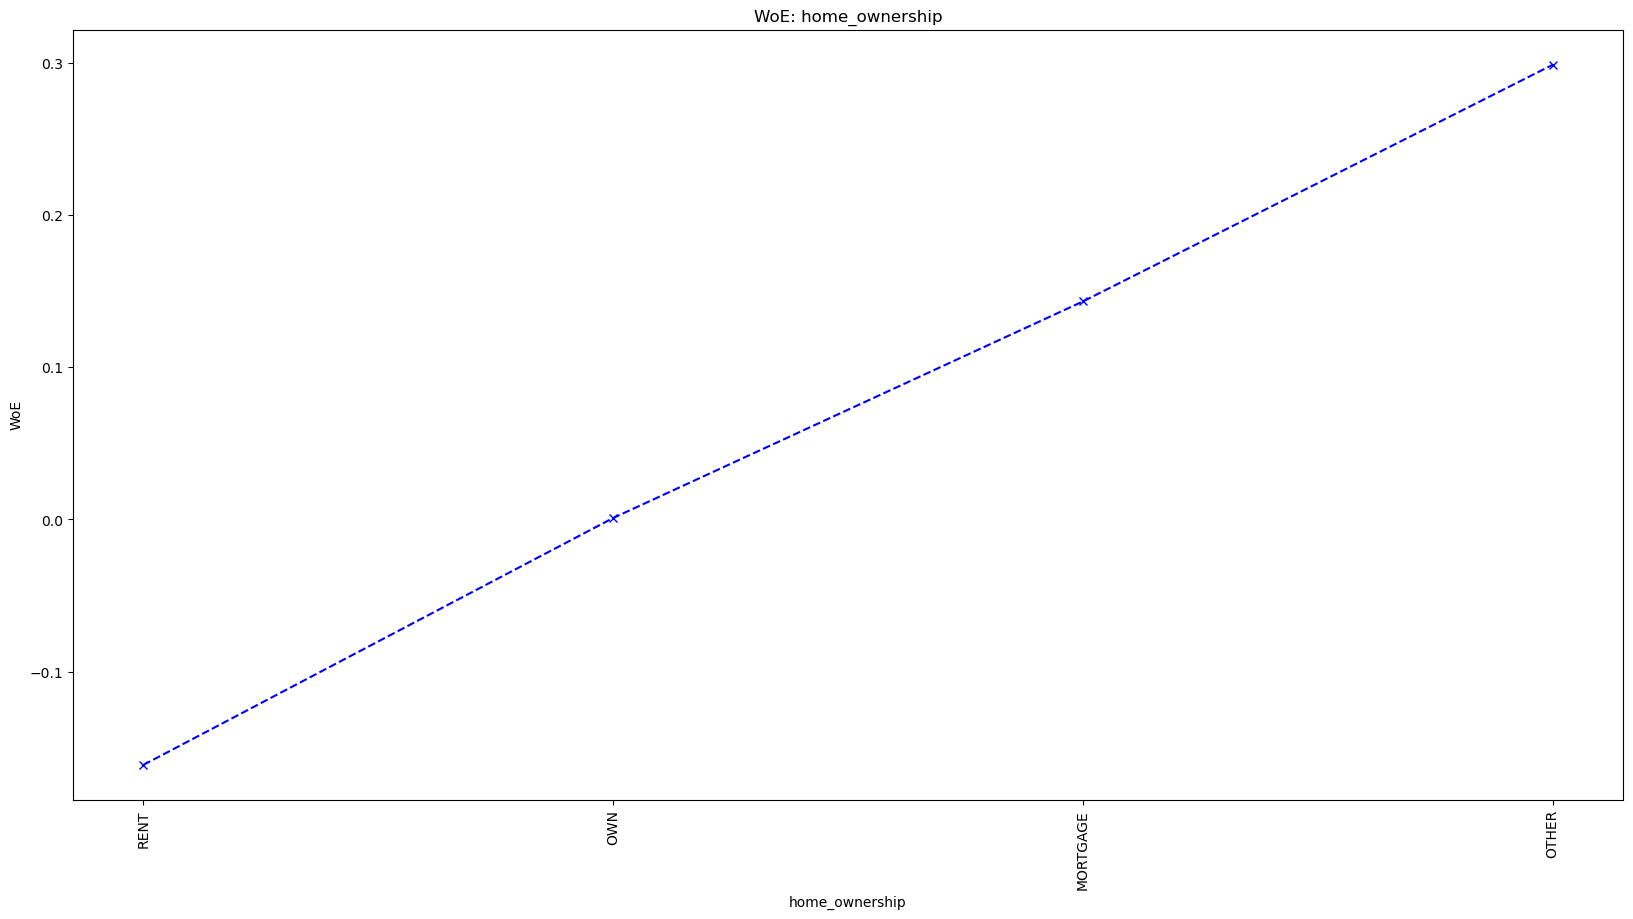

In [477]:
graph_WoE(df_test)

# Creating Dummies and Grouping

In [479]:
list(independent_training)

['Unnamed: 0',
 'id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_a

In [480]:
# Creating new variable "rent_other_any_none" based on WoE

In [481]:
independent_training['rent_other_any_none'] = sum([independent_training['home_RENT'], independent_training['home_ANY'],
                                                   independent_training['home_OTHER'],independent_training['home_NONE']])

In [482]:
independent_training['rent_other_any_none']

89223     0
158835    0
108909    0
270155    1
23971     1
         ..
153887    0
262432    1
13258     1
405904    1
278472    1
Name: rent_other_any_none, Length: 46629, dtype: int32

In [483]:
# Creating dummies for "addr_state"

In [484]:
independent_training['addr_state'].unique()

array(['IL', 'HI', 'MI', 'CA', 'NJ', 'VA', 'LA', 'WI', 'TX', 'OK', 'MN',
       'AZ', 'DE', 'NY', 'MA', 'FL', 'OH', 'WA', 'GA', 'CO', 'IN', 'NM',
       'SC', 'WV', 'NH', 'KS', 'UT', 'AL', 'PA', 'MD', 'WY', 'CT', 'NC',
       'TN', 'AR', 'NV', 'KY', 'VT', 'MO', 'RI', 'OR', 'DC', 'AK', 'MT',
       'SD', 'MS', 'IA', 'ID', 'NE'], dtype=object)

In [485]:
# Generate tabke with WoE function

In [486]:
df = WoE_categorical(independent_training, 'addr_state', dependent_training)

In [487]:
df

,addr_state,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status,WoE,delta_prop_n_good,delta_WoE,VI,sumVI
0,NE,2,0.500000,0.000043,1.0,1.0,0.000024,0.000228,-2.266028,NaN,NaN,4.634843e-04,0.019946
1,UT,317,0.861199,0.006798,273.0,44.0,0.006462,0.010041,-0.440746,0.006438,1.825282,1.577465e-03,0.019946
2,NV,676,0.884615,0.014497,598.0,78.0,0.014155,0.017800,-0.229146,0.007693,0.211600,8.352928e-04,0.019946
3,OK,408,0.889706,0.008750,363.0,45.0,0.008592,0.010269,-0.178288,0.005563,0.050858,2.989810e-04,0.019946
4,LA,600,0.893333,0.012868,536.0,64.0,0.012687,0.014605,-0.140777,0.004095,0.037511,2.699979e-04,0.019946
5,FL,3116,0.894095,0.066825,2786.0,330.0,0.065946,0.075308,-0.132759,0.053258,0.008018,1.242961e-03,0.019946
6,NM,239,0.895397,0.005126,214.0,25.0,0.005065,0.005705,-0.118928,0.060880,0.013831,7.607926e-05,0.019946
7,PA,1631,0.896383,0.034978,1462.0,169.0,0.034606,0.038567,-0.108366,0.029541,0.010562,4.292229e-04,0.019946
8,VA,1382,0.896527,0.029638,1239.0,143.0,0.029328,0.032634,-0.106813,0.005278,0.001553,3.531206e-04,0.019946
9,DE,136,0.897059,0.002917,122.0,14.0,0.002888,0.003195,-0.101064,0.026440,0.005748,3.103780e-05,0.019946


In [488]:
# It's important to note that in this dataset there are no observations for North Dakota
# I will include North Dakota for the sake of completedness
if ['address_ND'] in independent_training.columns.values:
    pass
else:
    independent_training['address_ND'] = 0

In [489]:
list(independent_training)

['Unnamed: 0',
 'id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_a

In [490]:
# Graph WoE

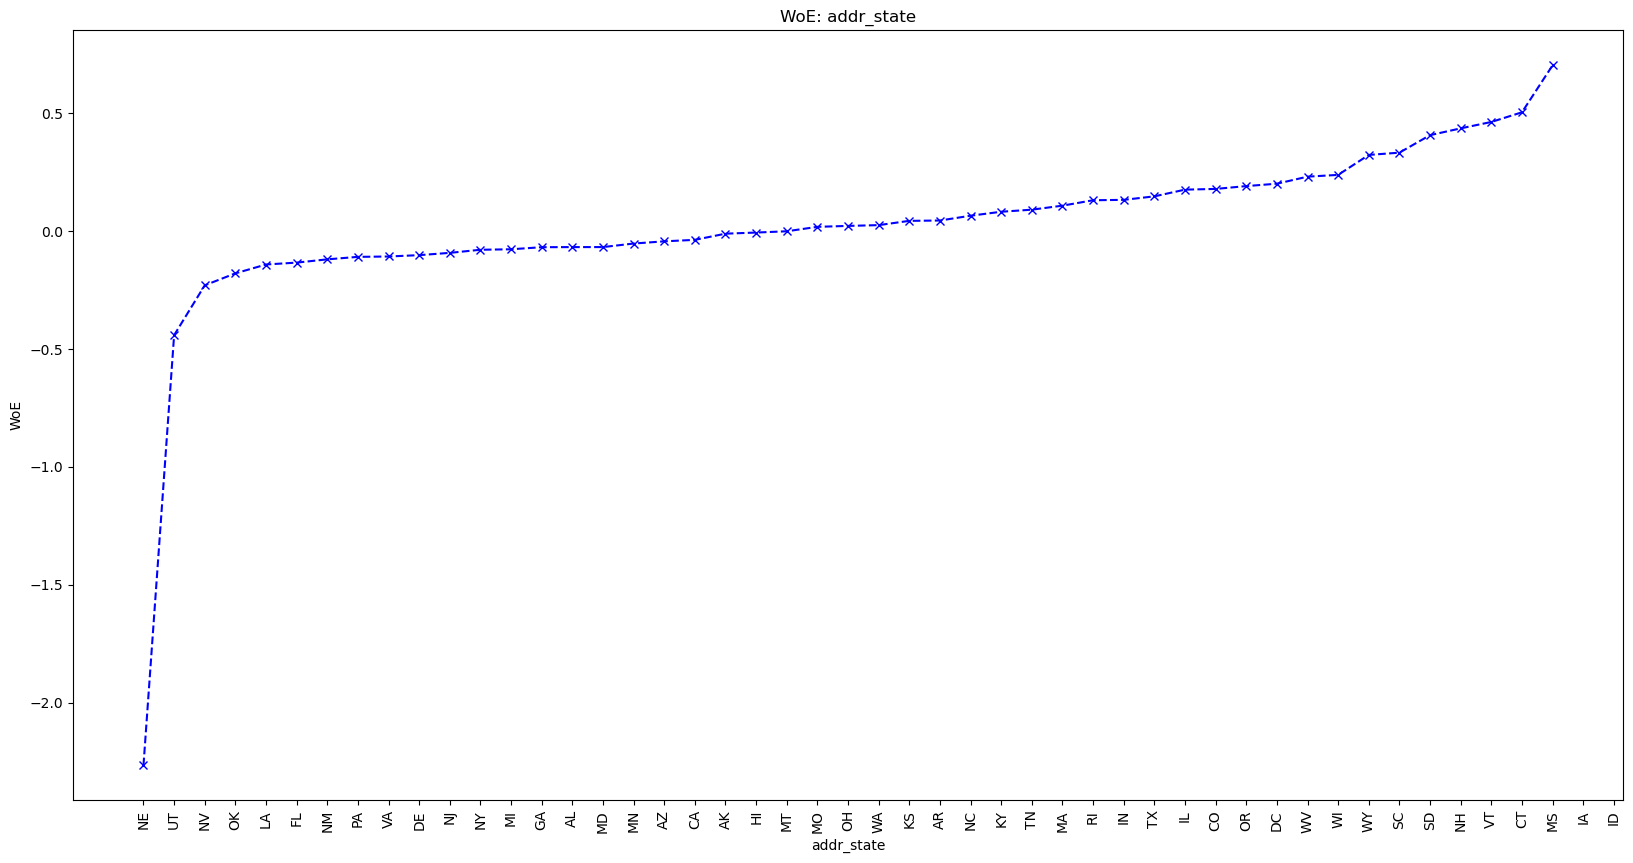

In [491]:
graph_WoE(df)

In [492]:
# The first two observations have a very low WoE and the last observation is infinity, this is due to the low number of observations for these states.
# We will remove these observations from the graphs for now

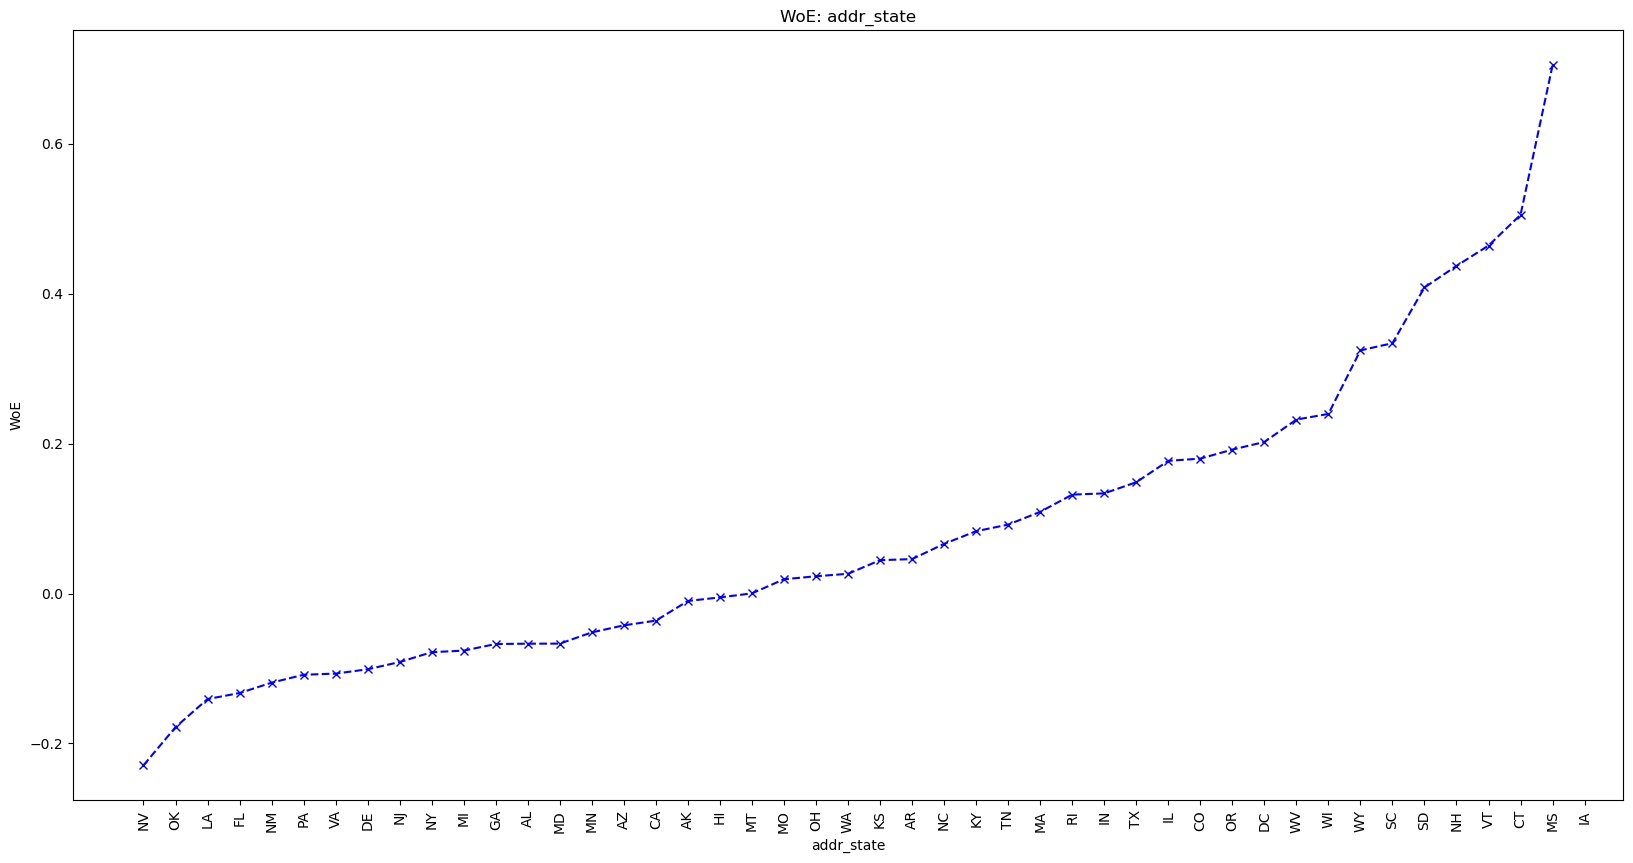

In [493]:
graph_WoE(df.iloc[2:-1,:])

In [494]:
# We will keep the states that have a proportion of observations well above 2% on their own category. These will be California, Texas, Florida, New York.
# For the rest we will observe the graph and group them when we notice a big jump on WoE
# Discliamer: These groupings are very subjective, feel free to choose your own groupings

In [495]:
# Grouping adress_ND_NE__IA_NV

In [496]:
independent_training['address_ND_NE_IA_NV'] = sum([independent_training['address_ND'],
                                                 independent_training['address_NE'],
                                                  independent_training['address_IA'],
                                                 independent_training['address_NV']])

In [497]:
#Grouping address_AL_HI_MO_NM

In [498]:
independent_training['address_AL_HI_MO_NM'] = sum([independent_training['address_AL'],
                                                 independent_training['address_HI'],
                                                  independent_training['address_MO'],
                                                 independent_training['address_NM']])

In [499]:
# Grouping adress_NC_ID_NJ

In [500]:
independent_training['address_NC_ID_NJ'] = sum([independent_training['address_NC'],
                                                 independent_training['address_ID'],
                                                  independent_training['address_NJ'],
                                                ])

In [501]:
# grouping adress_KY_LA_MD

In [502]:
independent_training['address_KY_LA_MD'] = sum([independent_training['address_KY'],
                                                 independent_training['address_LA'],
                                                  independent_training['address_MD'],
                                                ])

In [503]:
# grouping address_MI_AR_AZ_VA_OK_DE_OH

In [504]:
independent_training['address_MI_AR_AZ_VA_OK_DE_OH'] = sum([independent_training['address_MI'],
                                                         independent_training['address_AR'],
                                                          independent_training['address_AZ'],
                                                         independent_training['address_VA'],
                                                           independent_training['address_OK'],
                                                        independent_training['address_DE'],
                                                           independent_training['address_OH']])

In [505]:
# grouping address_MN_PA_UT_MA_RI_WA_TN_IN

In [506]:
independent_training['address_MN_PA_UT_MA_RI_WA_TN_IN'] = sum([independent_training['address_MN'],
                                                         independent_training['address_PA'],
                                                          independent_training['address_UT'],
                                                         independent_training['address_MA'],
                                                           independent_training['address_RI'],
                                                        independent_training['address_WA'],
                                                           independent_training['address_TN'],
                                                              independent_training['address_IN']])

In [507]:
# grouping address_OR_SD_WI_GA

In [508]:
independent_training['addressOR_SD_WI_GA'] = sum([independent_training['address_OR'],
                                                 independent_training['address_SD'],
                                                  independent_training['address_WI'],
                                                 independent_training['address_GA']])

In [509]:
# grouping address_CT_IL

In [510]:
independent_training['address_CT_IL'] = sum([independent_training['address_CT'],
                                                 independent_training['address_IL']
                                                ])

In [511]:
# grouping address_NH_AK_MT_MS_WY_WV_DC_ME

In [512]:
independent_training['address_NH_AK_MT_MS_WY_WV_DC_ME'] = sum([independent_training['address_NH'],
                                                         independent_training['address_AK'],
                                                          independent_training['address_MT'],
                                                         independent_training['address_MS'],
                                                           independent_training['address_WY'],
                                                        independent_training['address_WV'],
                                                           independent_training['address_DC'],
                                                              independent_training['address_ME']])

In [513]:
# creating dummies for purpose variable

In [514]:
independent_training['purpose'].unique()

array(['credit_card', 'home_improvement', 'debt_consolidation', 'other',
       'major_purchase', 'vacation', 'house', 'moving', 'medical', 'car',
       'small_business', 'wedding', 'renewable_energy', 'educational'],
      dtype=object)

In [515]:
df = WoE_categorical(independent_training, 'purpose', dependent_training)

In [516]:
df

,purpose,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status,WoE,delta_prop_n_good,delta_WoE,VI,sumVI
0,educational,37,0.729730,0.000793,27.0,10.0,0.000639,0.002282,-1.272776,NaN,NaN,0.002091,0.041644
1,small_business,687,0.802038,0.014733,551.0,136.0,0.013042,0.031036,-0.866948,0.012403,0.405828,0.015600,0.041644
2,moving,311,0.845659,0.006670,263.0,48.0,0.006225,0.010954,-0.565075,0.006817,0.301873,0.002672,0.041644
3,renewable_energy,28,0.857143,0.000600,24.0,4.0,0.000568,0.000913,-0.474269,0.005657,0.090806,0.000163,0.041644
4,vacation,222,0.873874,0.004761,194.0,28.0,0.004592,0.006390,-0.330374,0.004024,0.143894,0.000594,0.041644
5,other,2353,0.878453,0.050462,2067.0,286.0,0.048927,0.065267,-0.288166,0.044335,0.042208,0.004709,0.041644
6,house,204,0.882353,0.004375,180.0,24.0,0.004261,0.005477,-0.251125,0.044666,0.037041,0.000305,0.041644
7,debt_consolidation,27453,0.903690,0.588754,24809.0,2644.0,0.587237,0.603377,-0.027115,0.582976,0.224011,0.000438,0.041644
8,medical,434,0.907834,0.009308,394.0,40.0,0.009326,0.009128,0.021443,0.577911,0.048558,0.000004,0.041644
9,major_purchase,1018,0.908644,0.021832,925.0,93.0,0.021895,0.021223,0.031166,0.012569,0.009723,0.000021,0.041644


In [517]:
# graph

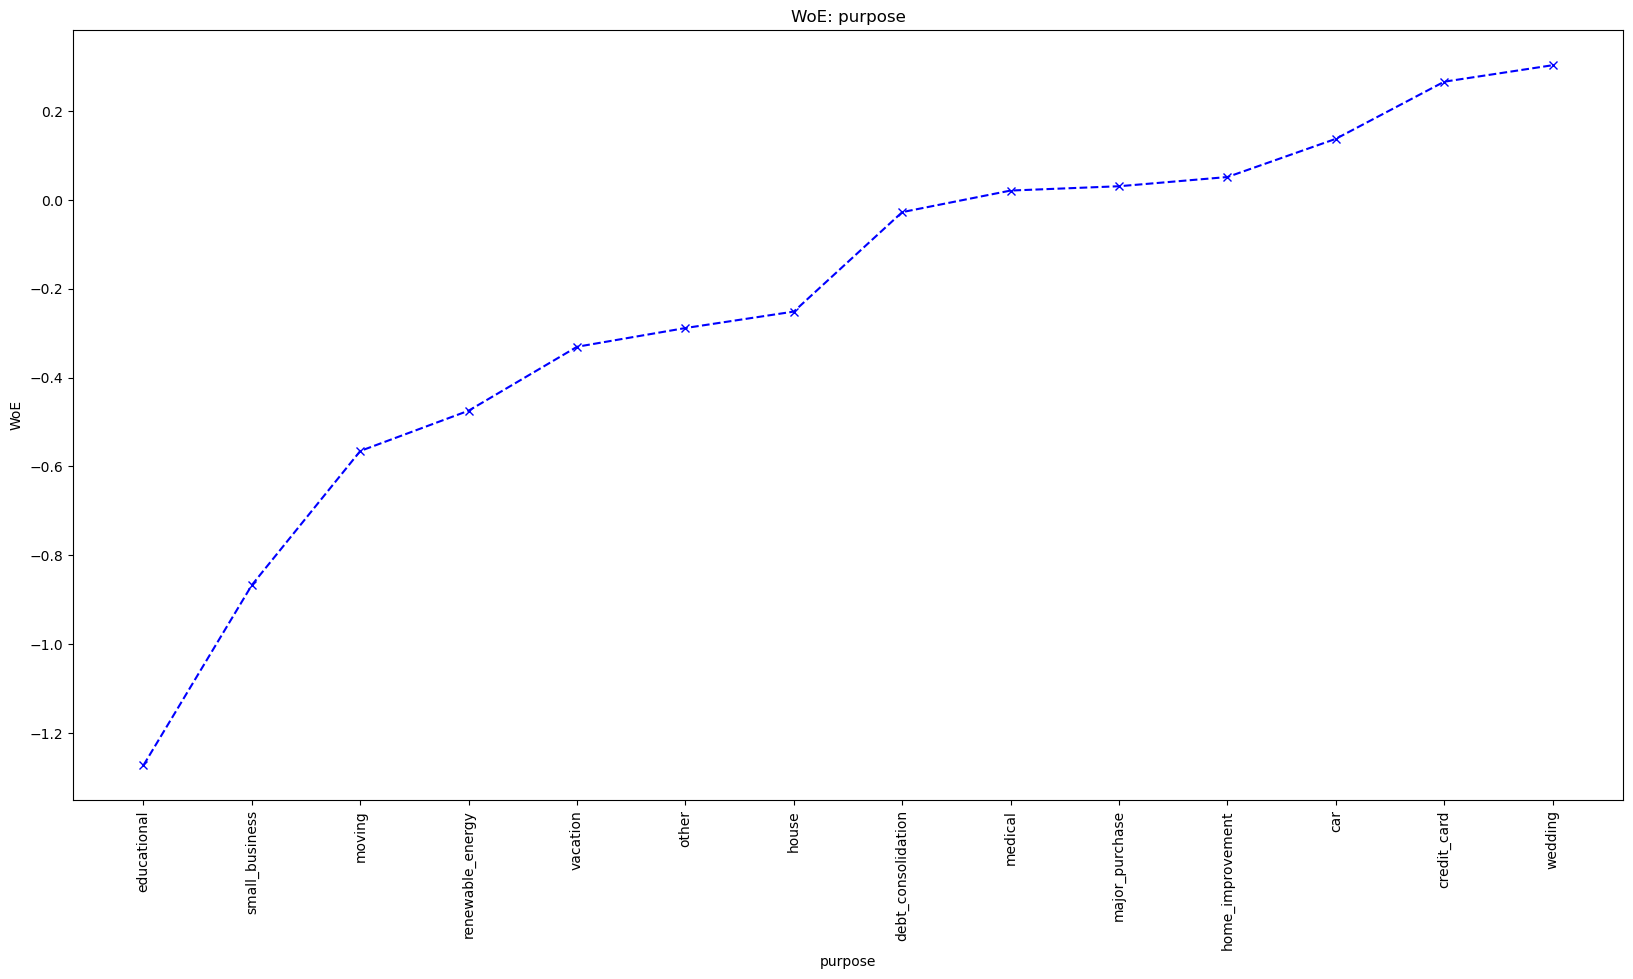

In [518]:
graph_WoE(df)

In [519]:
# Debt consolidation and credit card both have a sizeable proportion of observations so we won't group them
# Once again we will group based on WoE, very arbitrary so feel free to differ from my groupings


In [520]:
# grouping purpose_educational_small_business_renewable_moving

In [521]:
independent_training['purpose_educational_small_business_renewable_moving'] =     sum([independent_training['purpose_educational'],
                                                                                 independent_training['purpose_small_business'],
                                                                                  independent_training['purpose_renewable_energy'],
                                                                                 independent_training['purpose_moving']])

In [522]:
# grouping purpose_home_other_wedding_medical_vacation

In [523]:
independent_training['purpose_house_other_wedding_medical_vacation'] =     sum([independent_training['purpose_house'],
                                                                                 independent_training['purpose_other'],
                                                                                  independent_training['purpose_wedding'],
                                                                                 independent_training['purpose_medical'],
                                                                              independent_training['purpose_vacation']])

In [524]:
# grouping purpose_majorpurchase_homeimprovement_car

In [525]:
independent_training['purpose_majorpurchase_homeimprovement_car'] =     sum([independent_training['purpose_major_purchase'],
                                                                                 independent_training['purpose_home_improvement'],
                                                                                  independent_training['purpose_car'],])

# Automating calculation of WoE and VI for continuous variables

In [527]:
def WoE_continuous(X, categorical_variable, y):
    d = pd.concat([X[categorical_variable], y], axis=1)
    d.columns = [categorical_variable, "target"]

    out = d.groupby(categorical_variable, as_index=False)["target"].agg(
        observations="count",
        prop_good_status="mean"
    )

    out["prop_observations"] = out["observations"] / out["observations"].sum()
    out["n_good_status"] = out["prop_good_status"] * out["observations"]
    out["n_bad_status"] = (1 - out["prop_good_status"]) * out["observations"]

    out["total_prop_good_status"] = out["n_good_status"] / out["n_good_status"].sum()
    out["total_prop_bad_status"] = out["n_bad_status"] / out["n_bad_status"].sum()

    out["WoE"] = np.log(out["total_prop_good_status"] / out["total_prop_bad_status"])
    out.replace([np.inf, -np.inf], np.nan, inplace=True)

    #out = out.sort_values("WoE").reset_index(drop=True)
    out["delta_prop_n_good"] = out["total_prop_good_status"].diff().abs()
    out["delta_WoE"] = out["WoE"].diff().abs()

    out["VI"] = out["WoE"] * (out["total_prop_good_status"] - out["total_prop_bad_status"])
    out["sumVI"] = out["VI"].sum()

    return out

In [528]:
# For loan term there are only 36 months and 60 months so we will just create two new colums for these

In [529]:
independent_training['term_36'] = np.where(independent_training['term_num'] == 36,1,0)
independent_training['term_60'] = np.where(independent_training['term_num'] == 60,1,0)

In [530]:
# processing employment lengh

In [531]:
independent_training['emp_length_num'].unique()

array([ 3, 10,  2,  9,  5,  4,  0,  7,  6,  8,  1], dtype=int64)

In [532]:
df = WoE_continuous(independent_training,'emp_length_num',dependent_training)

In [533]:
df

,emp_length_num,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status,WoE,delta_prop_n_good,delta_WoE,VI,sumVI
0,0,5602,0.888611,0.120140,4978.0,624.0,0.117831,0.142401,-0.189395,NaN,NaN,0.004653,0.008954
1,1,2962,0.905469,0.063523,2682.0,280.0,0.063484,0.063898,-0.006500,0.054347,0.182895,0.000003,0.008954
2,2,4164,0.907541,0.089301,3779.0,385.0,0.089450,0.087859,0.017943,0.025966,0.024443,0.000029,0.008954
3,3,3635,0.908391,0.077956,3302.0,333.0,0.078159,0.075993,0.028113,0.011291,0.010170,0.000061,0.008954
4,4,2740,0.901825,0.058762,2471.0,269.0,0.058489,0.061387,-0.048361,0.019670,0.076474,0.000140,0.008954
5,5,3093,0.900420,0.066332,2785.0,308.0,0.065922,0.070288,-0.064125,0.007432,0.015763,0.000280,0.008954
6,6,2598,0.909546,0.055716,2363.0,235.0,0.055933,0.053628,0.042074,0.009989,0.106198,0.000097,0.008954
7,7,2610,0.904598,0.055974,2361.0,249.0,0.055886,0.056823,-0.016640,0.000047,0.058714,0.000016,0.008954
8,8,2286,0.907699,0.049025,2075.0,211.0,0.049116,0.048152,0.019830,0.006770,0.036471,0.000019,0.008954
9,9,1828,0.895514,0.039203,1637.0,191.0,0.038748,0.043587,-0.117681,0.010368,0.137511,0.000569,0.008954


In [534]:
# Graph


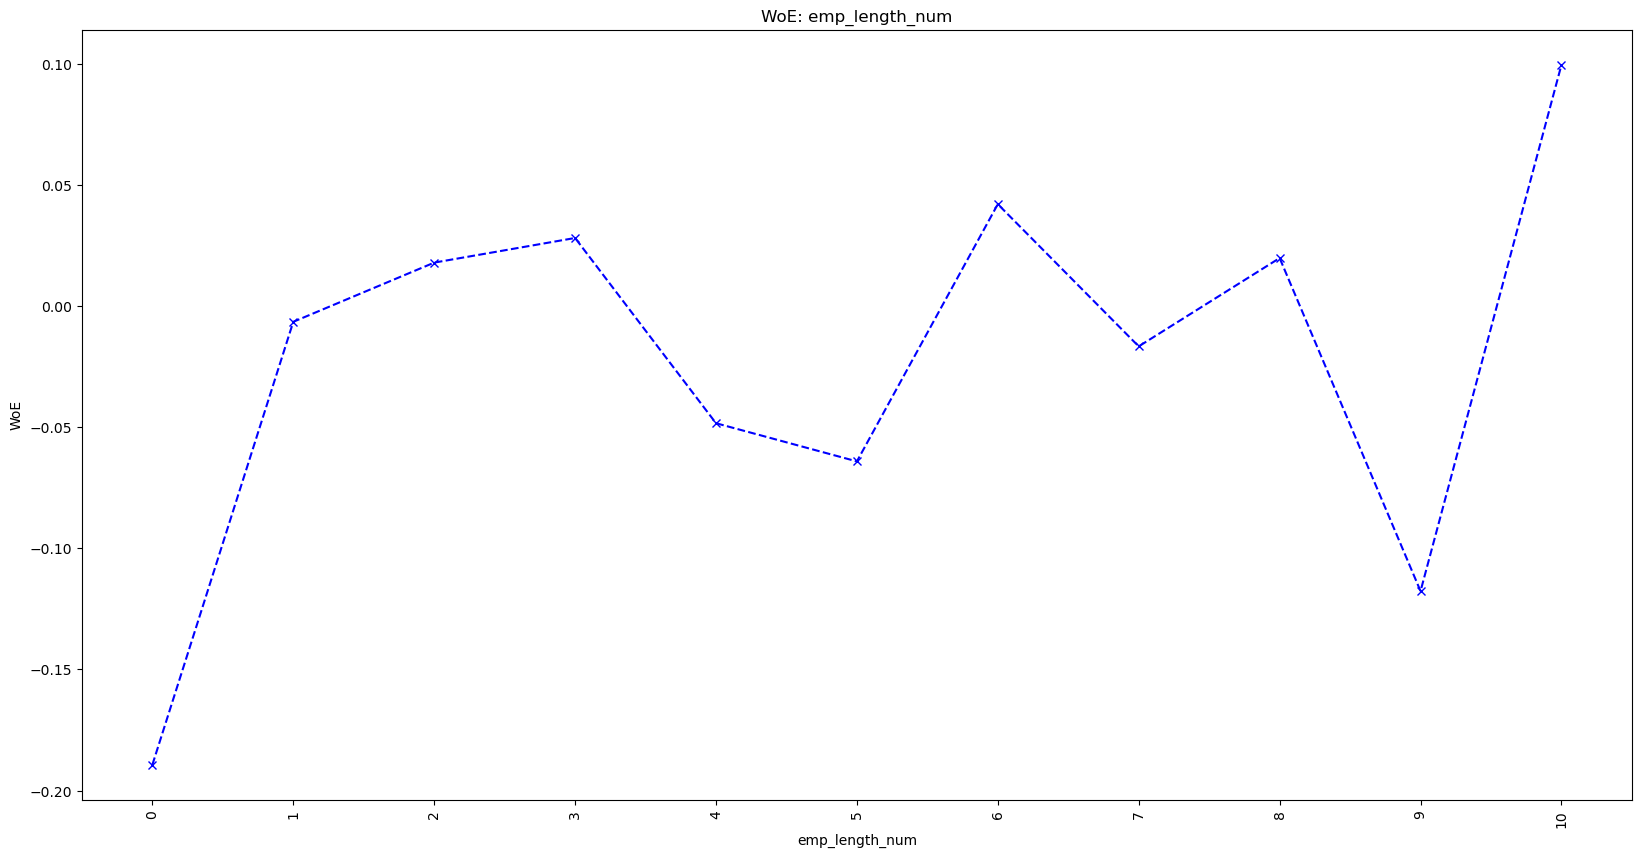

In [535]:
graph_WoE(df)

In [536]:
# Once again we will be grouping based on WoE however we can't violate the order of the years of employement so we can only group adjecent years
# less than a year (0) will be by itself

In [537]:
independent_training['emp_length_lessthan1'] = np.where(independent_training['emp_length_num'] == 0, 1, 0)

In [538]:
# grouping years 1-4

In [539]:
independent_training['emp_length_1_4'] = np.where(independent_training['emp_length_num'].isin(range(1, 5)), 1, 0)

In [540]:
# grouping years 5-6

In [541]:
independent_training['emp_length_5_6'] = np.where(independent_training['emp_length_num'].isin(range(5, 7)), 1, 0)

In [542]:
# 7 will be by itself

In [543]:
independent_training['emp_length_7'] = np.where(independent_training['emp_length_num'] == 7, 1, 0)

In [544]:
# grouping years 8-9

In [545]:
independent_training['emp_length_8_9'] = np.where(independent_training['emp_length_num'].isin(range(8, 10)), 1, 0)

In [546]:
# 10 + years will be by itself

In [547]:
independent_training['emp_length_10+'] = np.where(independent_training['emp_length_num'] == 10, 1, 0)

In [548]:
list(independent_training)

['Unnamed: 0',
 'id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_a

In [549]:
# processing months of credit

In [550]:
independent_training['credit_months'].unique()

array([100, 106, 101,  87, 134,  94, 108,  85,  86,  91,  93, 135, 167,
       102, 115, 107,  88, 127,  99, 103,  96, 116,  92,  90, 112, 110,
        97, 132, 119, 105, 146, 109, 118,  95, 113, 104,  89, 114, 143,
       111, 125, 140,  98, 117, 126, 136, 133, 144, 128, 120, 124, 148,
       166, 130, 123, 121, 147, 151, 139, 142, 137, 156, 141, 131, 154,
       129, 122, 150, 158, 157, 152, 168, 165, 138, 149, 153, 170, 145,
       171, 159, 164, 160, 169, 172, 155, 163, 161, 174, 162, 173, 175])

In [551]:
# This variable has a range between 85 - 175 months
# there are around 100 unique data values so we will have to do a two way classification
# first we will create around 50 bins with similar values
# then we will create new groupings based on WoE and number of observations

In [552]:
independent_training['credit_months_categories'] = pd.cut(independent_training['credit_months'],50)

In [553]:
independent_training['credit_months_categories']

89223      (99.4, 101.2]
158835    (104.8, 106.6]
108909     (99.4, 101.2]
270155      (86.8, 88.6]
23971     (133.6, 135.4]
               ...      
153887    (104.8, 106.6]
262432     (84.91, 86.8]
13258     (126.4, 128.2]
405904      (92.2, 94.0]
278472      (86.8, 88.6]
Name: credit_months_categories, Length: 46629, dtype: category
Categories (50, interval[float64, right]): [(84.91, 86.8] < (86.8, 88.6] < (88.6, 90.4] < (90.4, 92.2] ... (167.8, 169.6] < (169.6, 171.4] < (171.4, 173.2] < (173.2, 175.0]]

In [554]:
# now we can group based on WoE and number of observations

In [555]:
df = WoE_continuous(independent_training,'credit_months_categories',dependent_training)

C:\Users\matia\AppData\Local\Temp\ipykernel_11828\2187752545.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = d.groupby(categorical_variable, as_index=False)["target"].agg(


In [556]:
df

,credit_months_categories,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status,WoE,delta_prop_n_good,delta_WoE,VI,sumVI
0,"(84.91, 86.8]",3472,0.963710,0.074460,3346.0,126.0,0.079201,0.028754,1.013211,NaN,NaN,0.051113,0.206473
1,"(86.8, 88.6]",5008,0.947684,0.107401,4746.0,262.0,0.112339,0.059790,0.630685,0.033138,0.382526,0.033142,0.206473
2,"(88.6, 90.4]",4884,0.935913,0.104742,4571.0,313.0,0.108197,0.071429,0.415256,0.004142,0.215429,0.015268,0.206473
3,"(90.4, 92.2]",3562,0.919989,0.076390,3277.0,285.0,0.077568,0.065039,0.176166,0.030629,0.239090,0.002207,0.206473
4,"(92.2, 94.0]",3564,0.921717,0.076433,3285.0,279.0,0.077757,0.063670,0.199882,0.000189,0.023716,0.002816,0.206473
5,"(94.0, 95.8]",1539,0.920078,0.033005,1416.0,123.0,0.033517,0.028069,0.177379,0.044240,0.022503,0.000966,0.206473
6,"(95.8, 97.6]",3041,0.916475,0.065217,2787.0,254.0,0.065969,0.057964,0.129359,0.032452,0.048020,0.001035,0.206473
7,"(97.6, 99.4]",2884,0.899098,0.061850,2593.0,291.0,0.061377,0.066408,-0.078781,0.004592,0.208139,0.000396,0.206473
8,"(99.4, 101.2]",2565,0.910331,0.055009,2335.0,230.0,0.055270,0.052487,0.051660,0.006107,0.130440,0.000144,0.206473
9,"(101.2, 103.0]",2331,0.880738,0.049990,2053.0,278.0,0.048595,0.063441,-0.266592,0.006675,0.318252,0.003958,0.206473


In [557]:
# It's important to note that the number of observations declines significantly as credit months increases

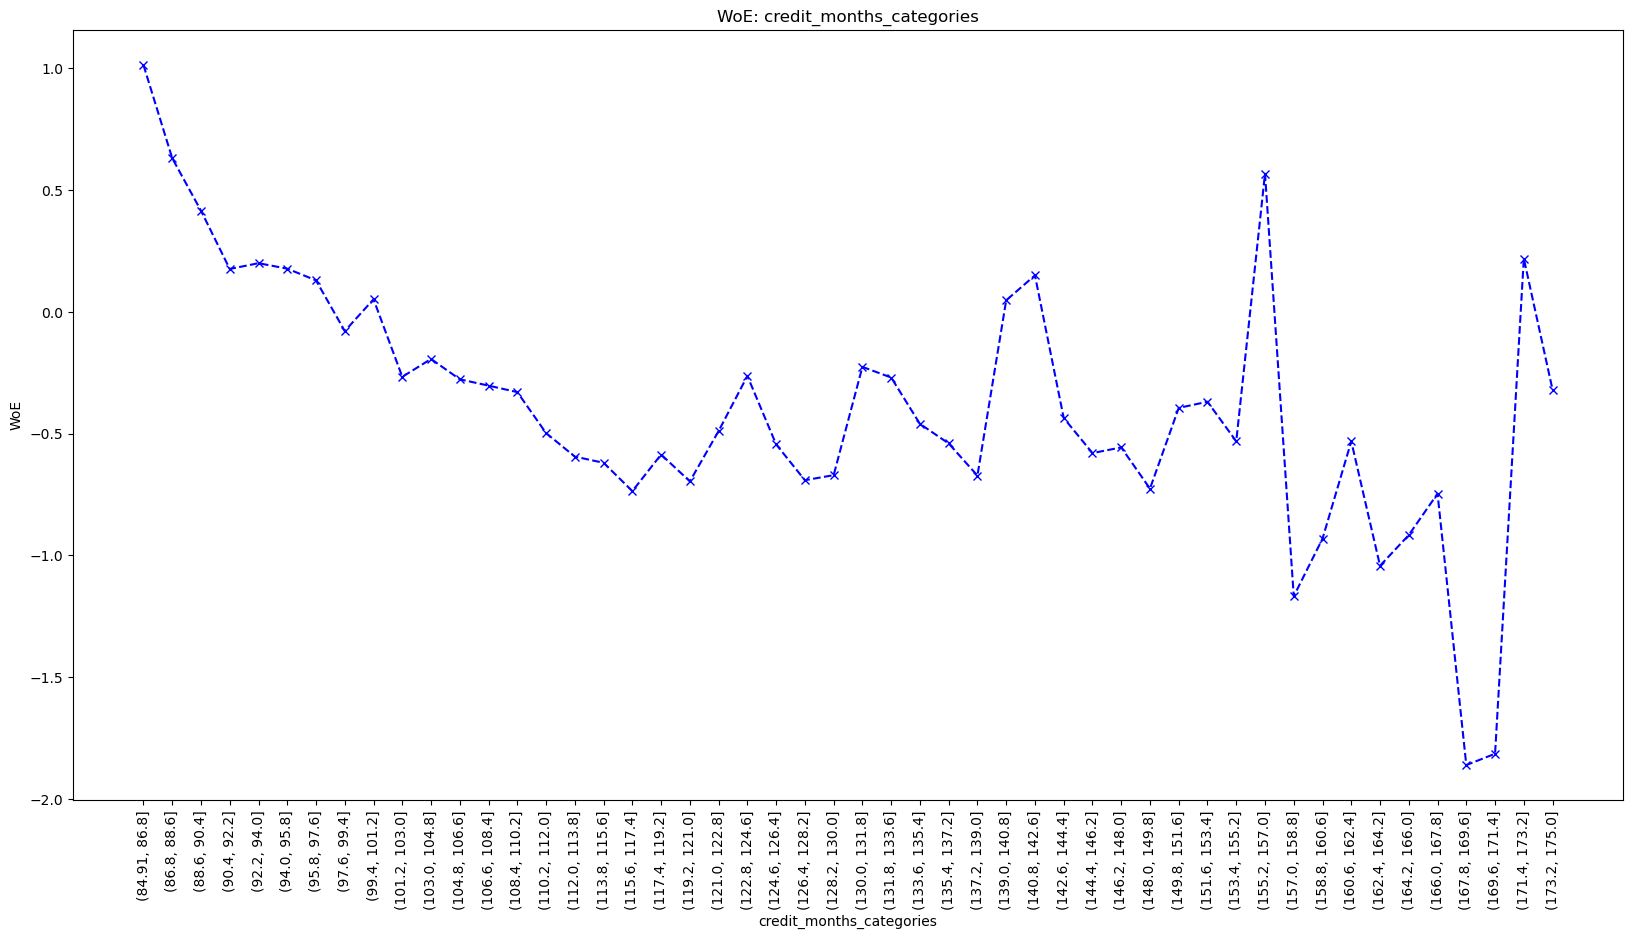

In [558]:
graph_WoE(df)

In [559]:
# The first 3 observations have a very pronounced fall, they will stay as separate categories and we will take them out of the graph for now

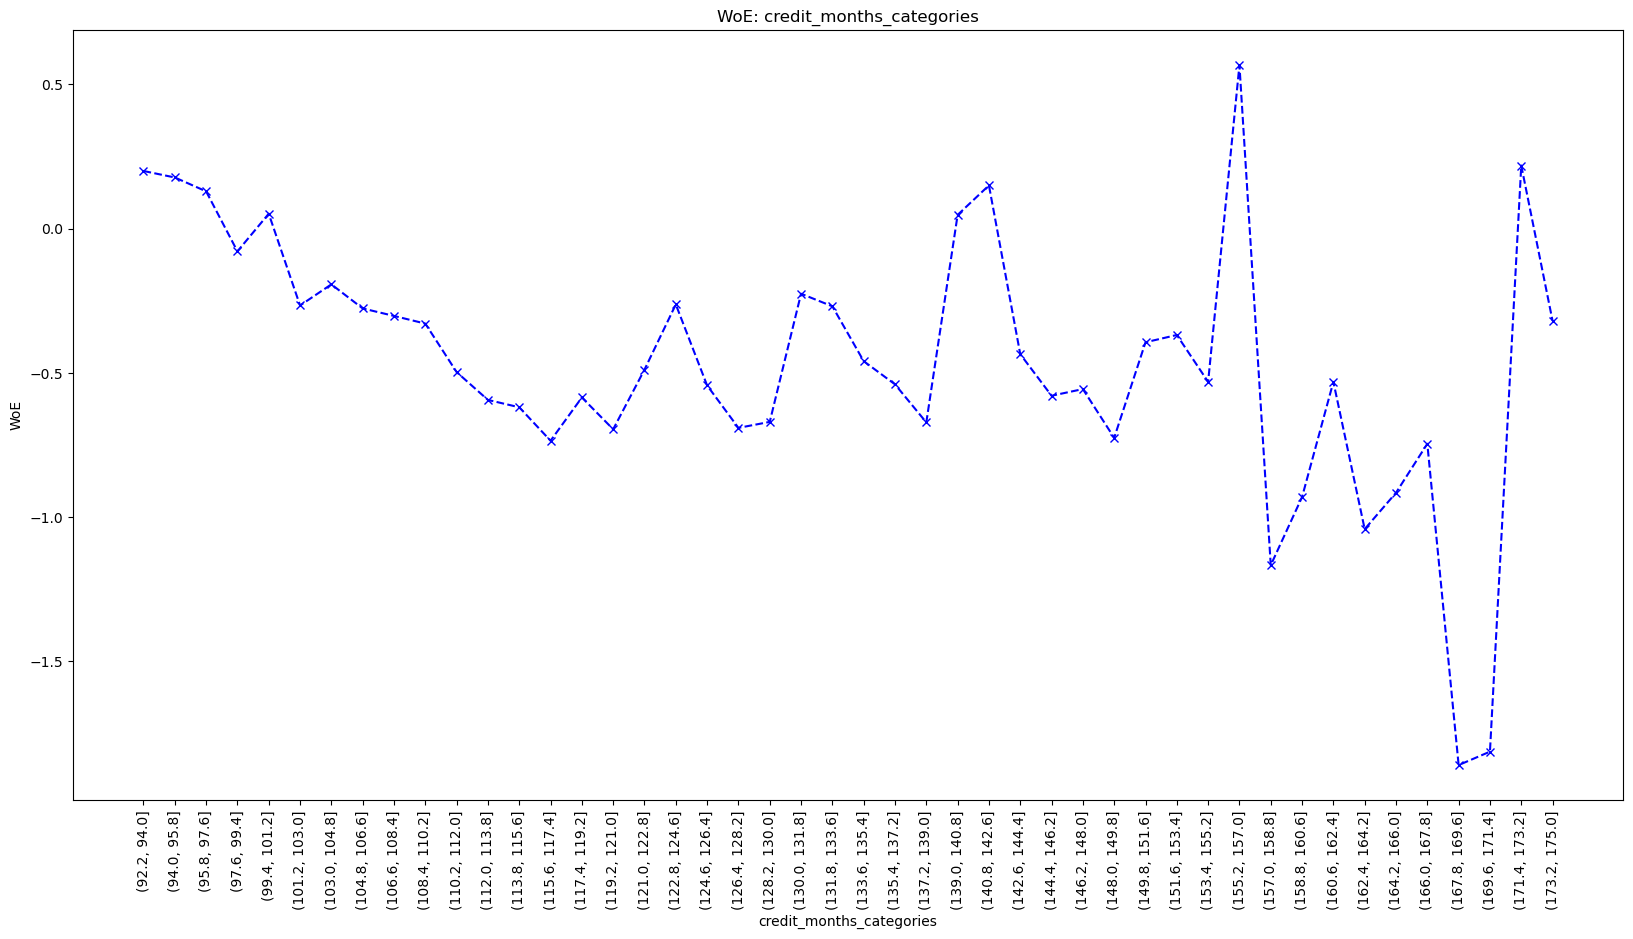

In [560]:
graph_WoE(df.iloc[4:,:])

In [561]:
# First group will be less than 87 months

In [562]:
independent_training['credit_months_<87'] = np.where(independent_training['credit_months'] < 87,1,0)

In [563]:
# Once again this is a highly arbitrary technique based on WoE and proportion of observations so feel free to differ from my groupings

In [564]:
independent_training['credit_months_87_89'] = np.where((independent_training['credit_months'] >= 87) & (independent_training['credit_months'] < 89),1,0)
independent_training['credit_months_89_90'] = np.where((independent_training['credit_months'] >= 89) & (independent_training['credit_months'] < 90),1,0)
independent_training['credit_months_90_98'] = np.where((independent_training['credit_months'] >= 90) & (independent_training['credit_months'] < 98),1,0)
independent_training['credit_months_98_101'] = np.where((independent_training['credit_months'] >= 98) & (independent_training['credit_months'] < 101),1,0)
independent_training['credit_months_101_110'] = np.where((independent_training['credit_months'] >= 101) & (independent_training['credit_months'] < 110),1,0)
independent_training['credit_months_110_126'] = np.where((independent_training['credit_months'] >= 110) & (independent_training['credit_months'] < 126),1,0)
independent_training['credit_months_126_155'] = np.where((independent_training['credit_months'] >= 126) & (independent_training['credit_months'] < 155),1,0)
independent_training['credit_months_>155'] = np.where(independent_training['credit_months'] >= 155,1,0)

In [565]:
# Processing annual income
# we will use exactly the same process we used for credit months

In [566]:
independent_training['annual_inc_categories'] = pd.cut(independent_training['annual_inc'],50)

In [567]:
df = WoE_continuous(independent_training,'annual_inc_categories',dependent_training)

C:\Users\matia\AppData\Local\Temp\ipykernel_11828\2187752545.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = d.groupby(categorical_variable, as_index=False)["target"].agg(


In [568]:
df

,annual_inc_categories,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status,WoE,delta_prop_n_good,delta_WoE,VI,sumVI
0,"(-1996.0, 123920.0]",42319,0.902550,0.907568,38195.0,4124.0,0.904088,0.941123,-0.040147,NaN,NaN,0.001487,0.020289
1,"(123920.0, 243840.0]",3865,0.938680,0.082888,3628.0,237.0,0.085876,0.054085,0.462349,0.818212,0.502496,0.014699,0.020289
2,"(243840.0, 363760.0]",341,0.953079,0.007313,325.0,16.0,0.007693,0.003651,0.745208,0.078183,0.282860,0.003012,0.020289
3,"(363760.0, 483680.0]",58,0.965517,0.001244,56.0,2.0,0.001326,0.000456,1.066176,0.006367,0.320968,0.000927,0.020289
4,"(483680.0, 603600.0]",28,0.928571,0.000600,26.0,2.0,0.000615,0.000456,0.298921,0.000710,0.767255,0.000048,0.020289
5,"(603600.0, 723520.0]",5,0.800000,0.000107,4.0,1.0,0.000095,0.000228,-0.879734,0.000521,1.178655,0.000117,0.020289
6,"(723520.0, 843440.0]",5,1.000000,0.000107,5.0,0.0,0.000118,0.000000,NaN,0.000024,NaN,NaN,0.020289
7,"(843440.0, 963360.0]",5,1.000000,0.000107,5.0,0.0,0.000118,0.000000,NaN,0.000000,NaN,NaN,0.020289
8,"(963360.0, 1083280.0]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.020289
9,"(1083280.0, 1203200.0]",1,1.000000,0.000021,1.0,0.0,0.000024,0.000000,NaN,NaN,NaN,NaN,0.020289


In [569]:
# As we can see from the chart around 95% of observations are in the less than $151,000 bucket. We will create a separate dataframe with these values to do our groupings

In [570]:
df_temp = independent_training.loc[independent_training['annual_inc'] <= 152000, :]

In [571]:
df_temp['annual_inc_categories'] = pd.cut(df_temp['annual_inc'],50)
df = WoE_continuous(df_temp,'annual_inc_categories',dependent_training)
df

C:\Users\matia\AppData\Local\Temp\ipykernel_11828\2444139781.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['annual_inc_categories'] = pd.cut(df_temp['annual_inc'],50)
C:\Users\matia\AppData\Local\Temp\ipykernel_11828\2187752545.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = d.groupby(categorical_variable, as_index=False)["target"].agg(


,annual_inc_categories,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status,WoE,delta_prop_n_good,delta_WoE,VI,sumVI
0,"(3852.0, 6960.0]",6,0.500000,0.000135,3.0,3.0,0.000074,0.000705,-2.249261,NaN,NaN,0.001419,0.056736
1,"(6960.0, 9920.0]",18,0.888889,0.000404,16.0,2.0,0.000397,0.000470,-0.169819,0.000322,2.079442,0.000012,0.056736
2,"(9920.0, 12880.0]",79,0.835443,0.001772,66.0,13.0,0.001636,0.003056,-0.624555,0.001240,0.454736,0.000887,0.056736
3,"(12880.0, 15840.0]",146,0.821918,0.003275,120.0,26.0,0.002975,0.006112,-0.719865,0.001339,0.095310,0.002258,0.056736
4,"(15840.0, 18800.0]",211,0.876777,0.004733,185.0,26.0,0.004587,0.006112,-0.287001,0.001612,0.432864,0.000438,0.056736
5,"(18800.0, 21760.0]",361,0.875346,0.008097,316.0,45.0,0.007835,0.010578,-0.300181,0.003248,0.013180,0.000823,0.056736
6,"(21760.0, 24720.0]",562,0.877224,0.012605,493.0,69.0,0.012224,0.016220,-0.282858,0.004389,0.017323,0.001130,0.056736
7,"(24720.0, 27680.0]",853,0.876905,0.019132,748.0,105.0,0.018547,0.024683,-0.285818,0.006323,0.002960,0.001754,0.056736
8,"(27680.0, 30640.0]",1334,0.867316,0.029920,1157.0,177.0,0.028688,0.041608,-0.371825,0.010141,0.086007,0.004804,0.056736
9,"(30640.0, 33600.0]",1027,0.876339,0.023035,900.0,127.0,0.022315,0.029854,-0.291053,0.006372,0.080772,0.002194,0.056736


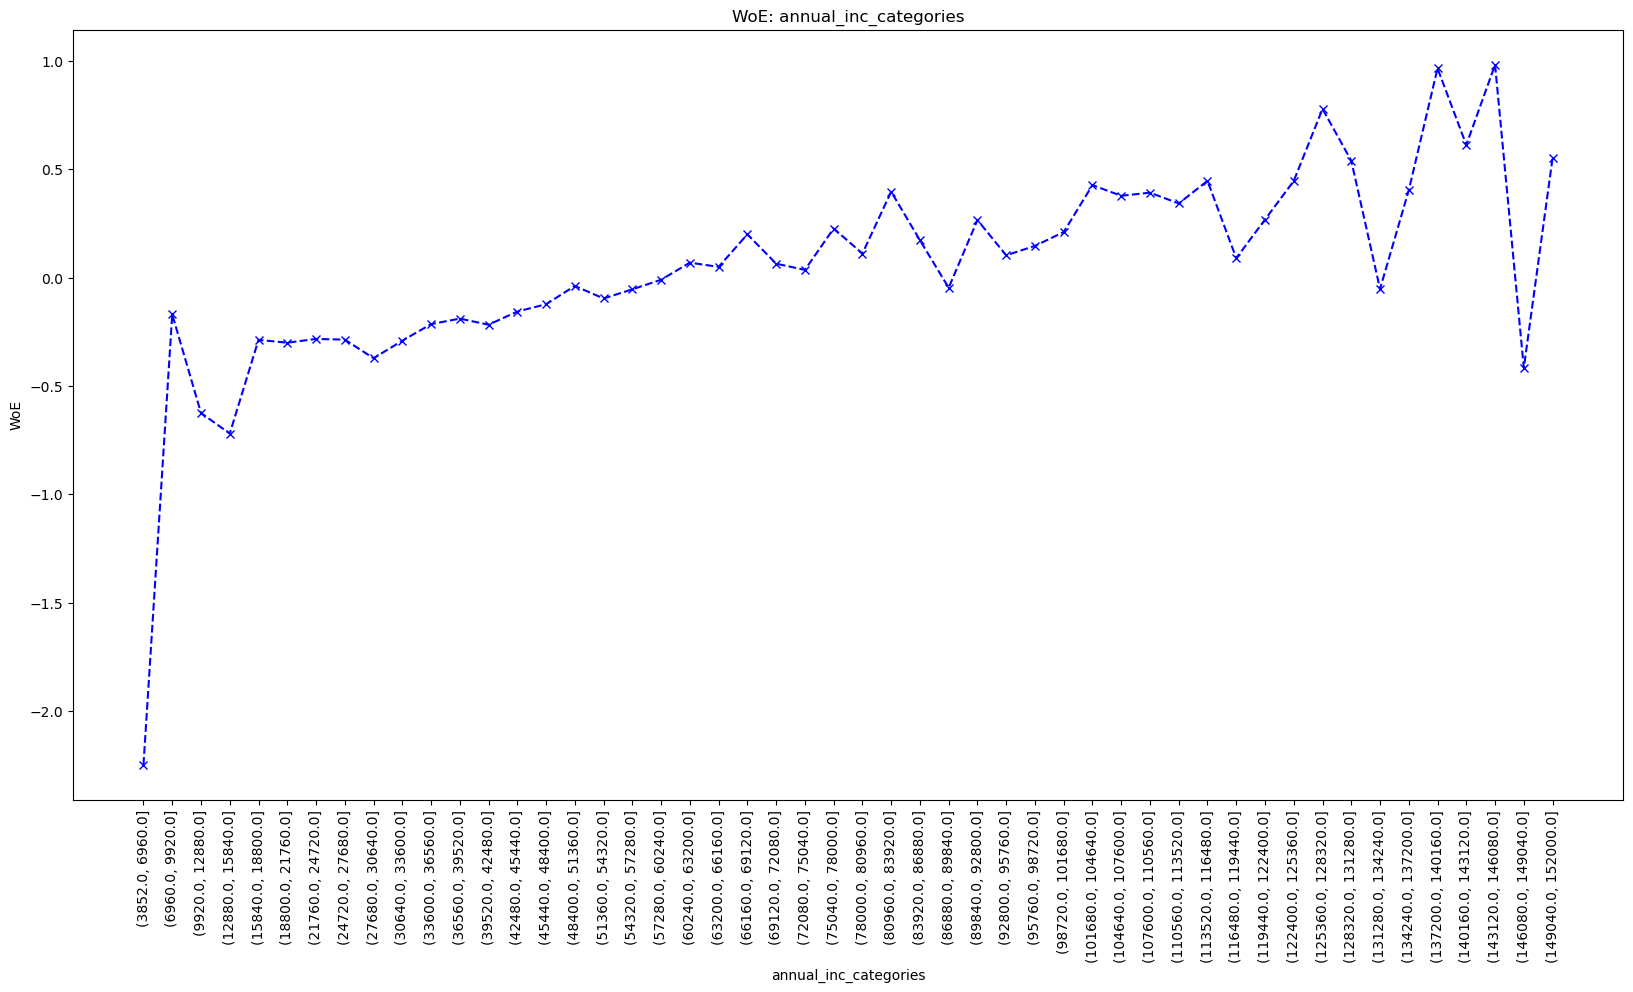

In [572]:
graph_WoE(df)

In [573]:
 # Once again this is a highly arbitrary technique based on WoE and proportion of observations so feel free to differ from my groupings

In [574]:
independent_training['annual_inc<20k'] = np.where(independent_training['annual_inc'] <= 20000,1,0)

In [575]:
independent_training['annual_inc_20_30'] = np.where(
    (independent_training['annual_inc'] > 20000) & (independent_training['annual_inc'] <= 30000), 1, 0)
independent_training['annual_inc_30_40'] = np.where(
    (independent_training['annual_inc'] > 30000) & (independent_training['annual_inc'] <= 40000), 1, 0)
independent_training['annual_inc_40_50'] = np.where(
    (independent_training['annual_inc'] > 40000) & (independent_training['annual_inc'] <= 50000), 1, 0)
independent_training['annual_inc_50_60'] = np.where(
    (independent_training['annual_inc'] > 50000) & (independent_training['annual_inc'] <= 60000), 1, 0)
independent_training['annual_inc_60_70'] = np.where(
    (independent_training['annual_inc'] > 60000) & (independent_training['annual_inc'] <= 70000), 1, 0)
independent_training['annual_inc_70_80'] = np.where(
    (independent_training['annual_inc'] > 70000) & (independent_training['annual_inc'] <= 80000), 1, 0)
independent_training['annual_inc_80_90'] = np.where(
    (independent_training['annual_inc'] > 80000) & (independent_training['annual_inc'] <= 90000), 1, 0)
independent_training['annual_inc_90_100'] = np.where(
    (independent_training['annual_inc'] > 90000) & (independent_training['annual_inc'] <= 100000), 1, 0)
independent_training['annual_inc_100_126'] = np.where(
    (independent_training['annual_inc'] > 100000) & (independent_training['annual_inc'] <= 126000), 1, 0)
independent_training['annual_inc_126_152'] = np.where(
    (independent_training['annual_inc'] > 126000) & (independent_training['annual_inc'] <= 152000), 1, 0)
independent_training['annual_inc_152_227'] = np.where(
    (independent_training['annual_inc'] > 152000) & (independent_training['annual_inc'] <= 227000), 1, 0)
independent_training['annual_inc>227k'] = np.where(
    independent_training['annual_inc'] > 227000, 1, 0)

In [576]:
# processing months since last delinquency
# not all customers have been delinquent so they don't have a numeric values
# therefore we will select all non null variables which we will process as continuous

In [577]:
independent_temp = independent_training[pd.notnull(independent_training['mths_since_last_delinq'])]

In [578]:
independent_training['mths_since_last_delinq_categories'] = pd.cut(independent_temp['mths_since_last_delinq'],50)

In [579]:
df = WoE_continuous(independent_training,'mths_since_last_delinq_categories',dependent_training)
df

C:\Users\matia\AppData\Local\Temp\ipykernel_11828\2187752545.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = d.groupby(categorical_variable, as_index=False)["target"].agg(


,mths_since_last_delinq_categories,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status,WoE,delta_prop_n_good,delta_WoE,VI,sumVI
0,"(-0.135, 2.7]",433,0.870670,0.019975,377.0,56.0,0.019106,0.028792,-0.410086,NaN,NaN,3.971994e-03,0.020223
1,"(2.7, 5.4]",835,0.914970,0.038520,764.0,71.0,0.038719,0.036504,0.058908,0.019613,0.468994,1.304803e-04,0.020223
2,"(5.4, 8.1]",1235,0.894737,0.056973,1105.0,130.0,0.056000,0.066838,-0.176914,0.017282,0.235822,1.917325e-03,0.020223
3,"(8.1, 10.8]",887,0.919955,0.040919,816.0,71.0,0.041354,0.036504,0.124755,0.014646,0.301668,6.050968e-04,0.020223
4,"(10.8, 13.5]",1202,0.917637,0.055450,1103.0,99.0,0.055899,0.050900,0.093689,0.014545,0.031065,4.683821e-04,0.020223
5,"(13.5, 16.2]",1200,0.895833,0.055358,1075.0,125.0,0.054480,0.064267,-0.165218,0.001419,0.258907,1.617037e-03,0.020223
6,"(16.2, 18.9]",794,0.915617,0.036629,727.0,67.0,0.036844,0.034447,0.067254,0.017636,0.232472,1.611682e-04,0.020223
7,"(18.9, 21.6]",1115,0.904933,0.051437,1009.0,106.0,0.051135,0.054499,-0.063704,0.014292,0.130958,2.142678e-04,0.020223
8,"(21.6, 24.3]",1014,0.908284,0.046778,921.0,93.0,0.046675,0.047815,-0.024119,0.004460,0.039585,2.748280e-05,0.020223
9,"(24.3, 27.0]",971,0.907312,0.044794,881.0,90.0,0.044648,0.046272,-0.035732,0.002027,0.011613,5.803574e-05,0.020223


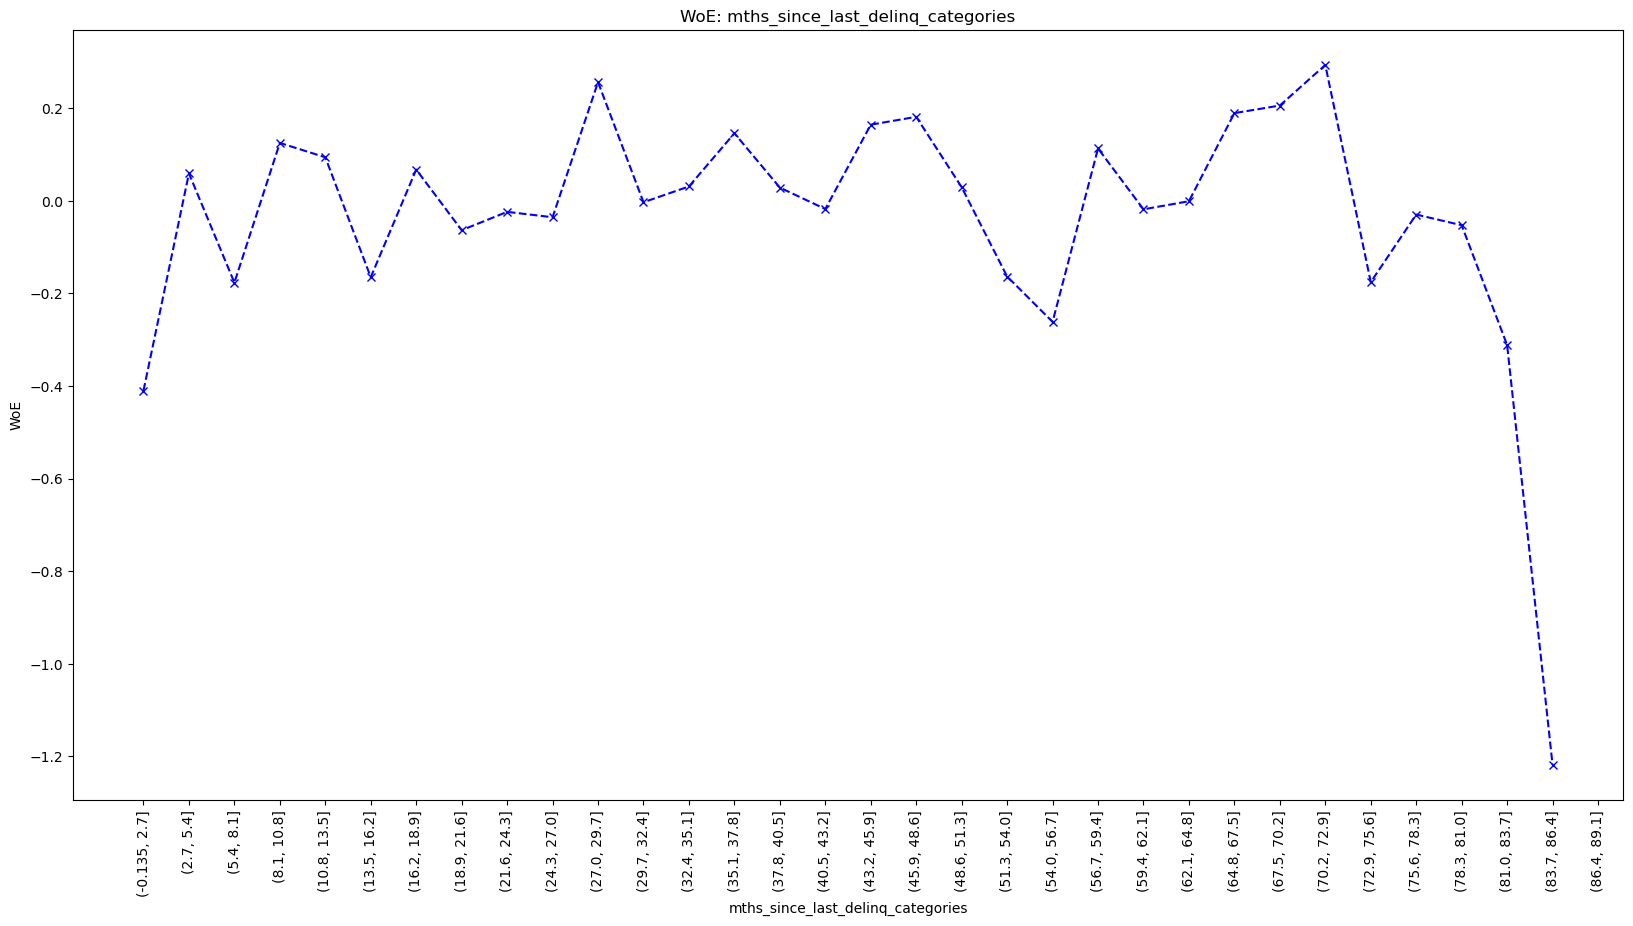

In [580]:
graph_WoE(df)

In [581]:
 # Once again this is a highly arbitrary technique based on WoE and proportion of observations so feel free to differ from my groupings

In [582]:
independent_training['mths_since_last_delinq_null'] = np.where((independent_training['mths_since_last_delinq'].isnull()),1,0)

In [583]:
independent_training['mths_since_last_delinq_0_4'] = np.where(independent_training['mths_since_last_delinq'].isin(range(0,4)),1,0)
independent_training['mths_since_last_delinq_4_30'] = np.where(independent_training['mths_since_last_delinq'].isin(range(4,30)),1,0)
independent_training['mths_since_last_delinq_30_60'] = np.where(independent_training['mths_since_last_delinq'].isin(range(30,60)),1,0)
independent_training['mths_since_last_delinq_60_83'] = np.where(independent_training['mths_since_last_delinq'].isin(range(60,83)),1,0)
independent_training['mths_since_last_delinq>83'] = np.where(independent_training['mths_since_last_delinq']> 83,1,0)

In [584]:
# Now processing delinq_2yrs ( delinquencies in the past 2 years)


In [585]:
independent_training['delinq_2yrs'].unique()

array([ 0.,  2.,  3.,  1.,  6.,  5.,  7.,  4.,  9.,  8., 13., 11., 18.,
       12., 10., 19.])

In [586]:
# We can procede without grouping in 50 bins

In [587]:
df = WoE_continuous(independent_training,'delinq_2yrs',dependent_training)
df

,delinq_2yrs,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status,WoE,delta_prop_n_good,delta_WoE,VI,sumVI
0,0.0,38255,0.905738,0.820412,34649.0,3606.0,0.820153,0.822912,-0.003358,NaN,NaN,9.265733e-06,0.002024
1,1.0,5676,0.907505,0.121727,5151.0,525.0,0.121926,0.119808,0.017520,0.698227,0.020878,3.709832e-05,0.002024
2,2.0,1644,0.908759,0.035257,1494.0,150.0,0.035363,0.034231,0.032549,0.086562,0.015029,3.686213e-05,0.002024
3,3.0,568,0.890845,0.012181,506.0,62.0,0.011977,0.014149,-0.166626,0.023386,0.199175,3.618461e-04,0.002024
4,4.0,227,0.942731,0.004868,214.0,13.0,0.005065,0.002967,0.534999,0.006912,0.701624,1.122837e-03,0.002024
5,5.0,117,0.897436,0.002509,105.0,12.0,0.002485,0.002738,-0.096974,0.002580,0.631973,2.454345e-05,0.002024
6,6.0,54,0.907407,0.001158,49.0,5.0,0.001160,0.001141,0.016354,0.001326,0.113329,3.076923e-07,0.002024
7,7.0,31,0.870968,0.000665,27.0,4.0,0.000639,0.000913,-0.356486,0.000521,0.372840,9.757958e-05,0.002024
8,8.0,22,0.863636,0.000472,19.0,3.0,0.000450,0.000685,-0.420201,0.000189,0.063716,9.869809e-05,0.002024
9,9.0,10,0.800000,0.000214,8.0,2.0,0.000189,0.000456,-0.879734,0.000260,0.459532,2.349329e-04,0.002024


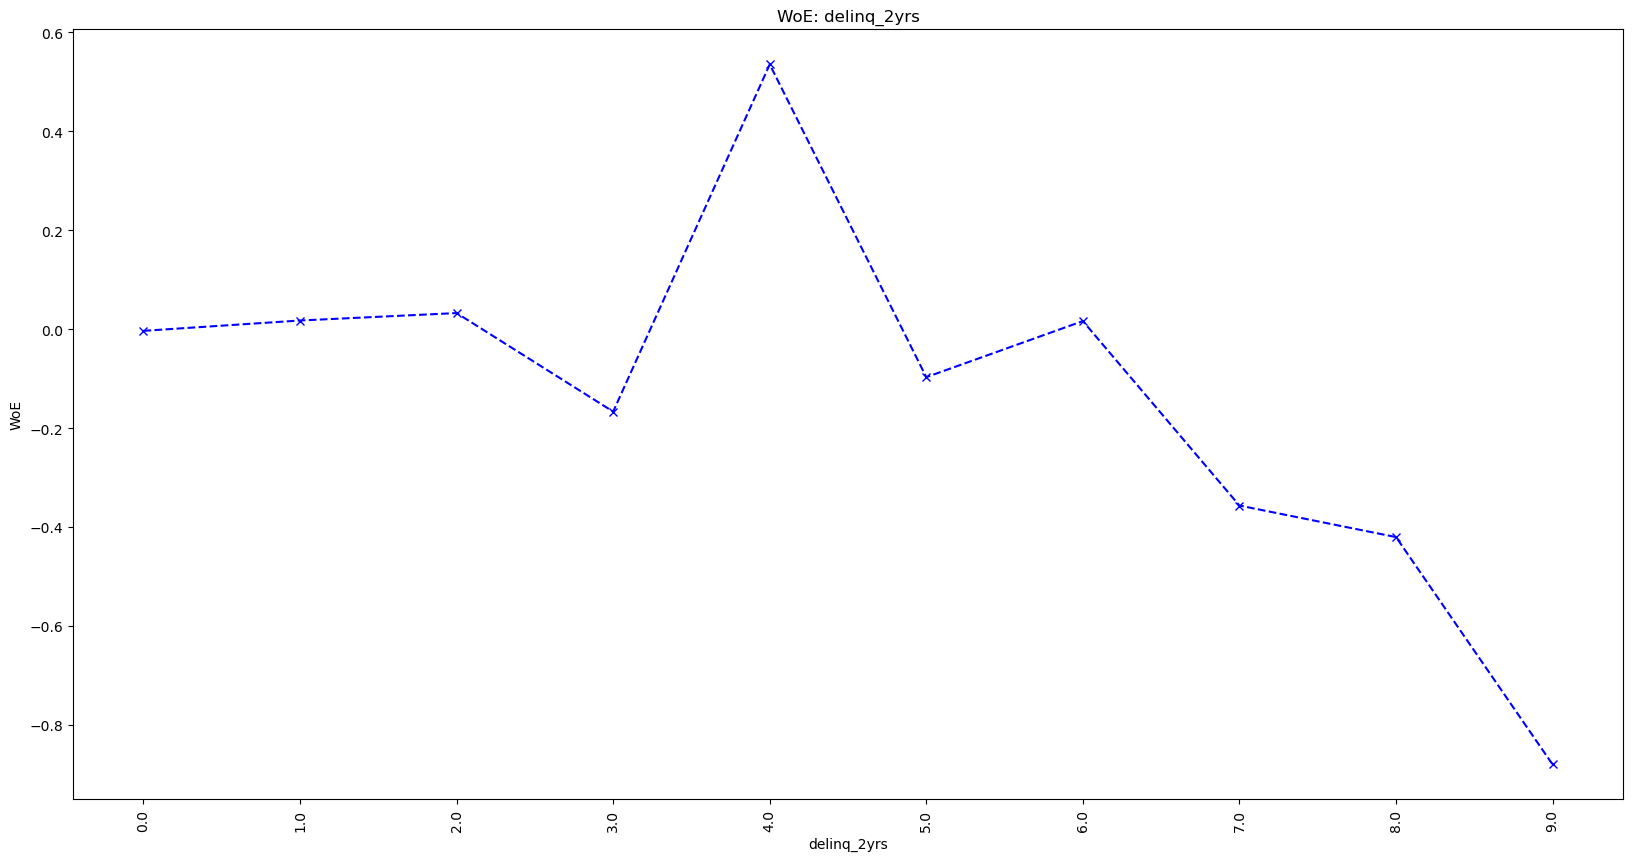

In [588]:
graph_WoE(df)

In [589]:
# Grouping based on WoE and proportions of observations

In [590]:
independent_training['delinq_2yrs_0'] = np.where(independent_training['delinq_2yrs'] == 0, 1,0)
independent_training['delinq_2yrs_1_4'] = np.where((independent_training['delinq_2yrs'] >= 1) & (independent_training['delinq_2yrs'] <= 4), 1, 0)
independent_training['delinq_2yrs>=5'] = np.where((independent_training['delinq_2yrs'] >= 5), 1, 0)

In [591]:
# Processing Total Account

In [592]:
independent_training['total_acc'].unique()

array([ 20.,  30.,  23.,  29.,  36.,  17.,  14.,  58.,  15.,  34.,  44.,
        32.,  42.,  24.,  21.,  12.,  25.,  28.,  10.,  19.,  35.,  41.,
        13.,  27.,  26.,  22.,  53.,  38.,  16.,  18.,   8.,  33.,  61.,
        47.,  43.,   9.,   4.,   6.,  54.,  11.,  31.,  55.,  63.,   5.,
         7.,  39.,  45.,  40.,  74.,  56.,  51.,  59.,  48.,  49.,  37.,
        46.,  57.,  62.,  50.,   3.,  52.,  64.,  67.,  60.,  69.,  81.,
        65.,  66.,  72.,  71.,  85.,  76.,  87.,  70.,  73.,  68., 100.,
         0.,  91.,   2.,  79., 117.,   1.,  86.,  82.,  97.,  78.,  77.,
        89.])

In [593]:
independent_training['total_acc_categories'] = pd.cut(independent_training['total_acc'],50)

In [594]:
df = WoE_continuous(independent_training,'total_acc_categories',dependent_training)
df

C:\Users\matia\AppData\Local\Temp\ipykernel_11828\2187752545.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = d.groupby(categorical_variable, as_index=False)["target"].agg(


,total_acc_categories,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status,WoE,delta_prop_n_good,delta_WoE,VI,sumVI
0,"(-0.117, 2.34]",8,0.625000,0.000172,5.0,3.0,0.000118,0.000685,-1.755202,NaN,NaN,0.000994,0.022043
1,"(2.34, 4.68]",225,0.840000,0.004825,189.0,36.0,0.004474,0.008215,-0.607800,0.004355,1.147402,0.002274,0.022043
2,"(4.68, 7.02]",1041,0.869356,0.022325,905.0,136.0,0.021422,0.031036,-0.370748,0.016948,0.237052,0.003565,0.022043
3,"(7.02, 9.36]",1339,0.893951,0.028716,1197.0,142.0,0.028333,0.032405,-0.134281,0.006912,0.236467,0.000547,0.022043
4,"(9.36, 11.7]",1982,0.888496,0.042506,1761.0,221.0,0.041683,0.050434,-0.190554,0.013350,0.056272,0.001667,0.022043
5,"(11.7, 14.04]",3850,0.901299,0.082567,3470.0,380.0,0.082136,0.086718,-0.054289,0.040453,0.136264,0.000249,0.022043
6,"(14.04, 16.38]",3034,0.896836,0.065067,2721.0,313.0,0.064407,0.071429,-0.103477,0.017729,0.049187,0.000727,0.022043
7,"(16.38, 18.72]",3370,0.908605,0.072273,3062.0,308.0,0.072479,0.070288,0.030696,0.008072,0.134172,0.000067,0.022043
8,"(18.72, 21.06]",5073,0.902622,0.108795,4579.0,494.0,0.108386,0.112734,-0.039328,0.035908,0.070023,0.000171,0.022043
9,"(21.06, 23.4]",3401,0.905028,0.072937,3078.0,323.0,0.072857,0.073711,-0.011645,0.035529,0.027683,0.000010,0.022043


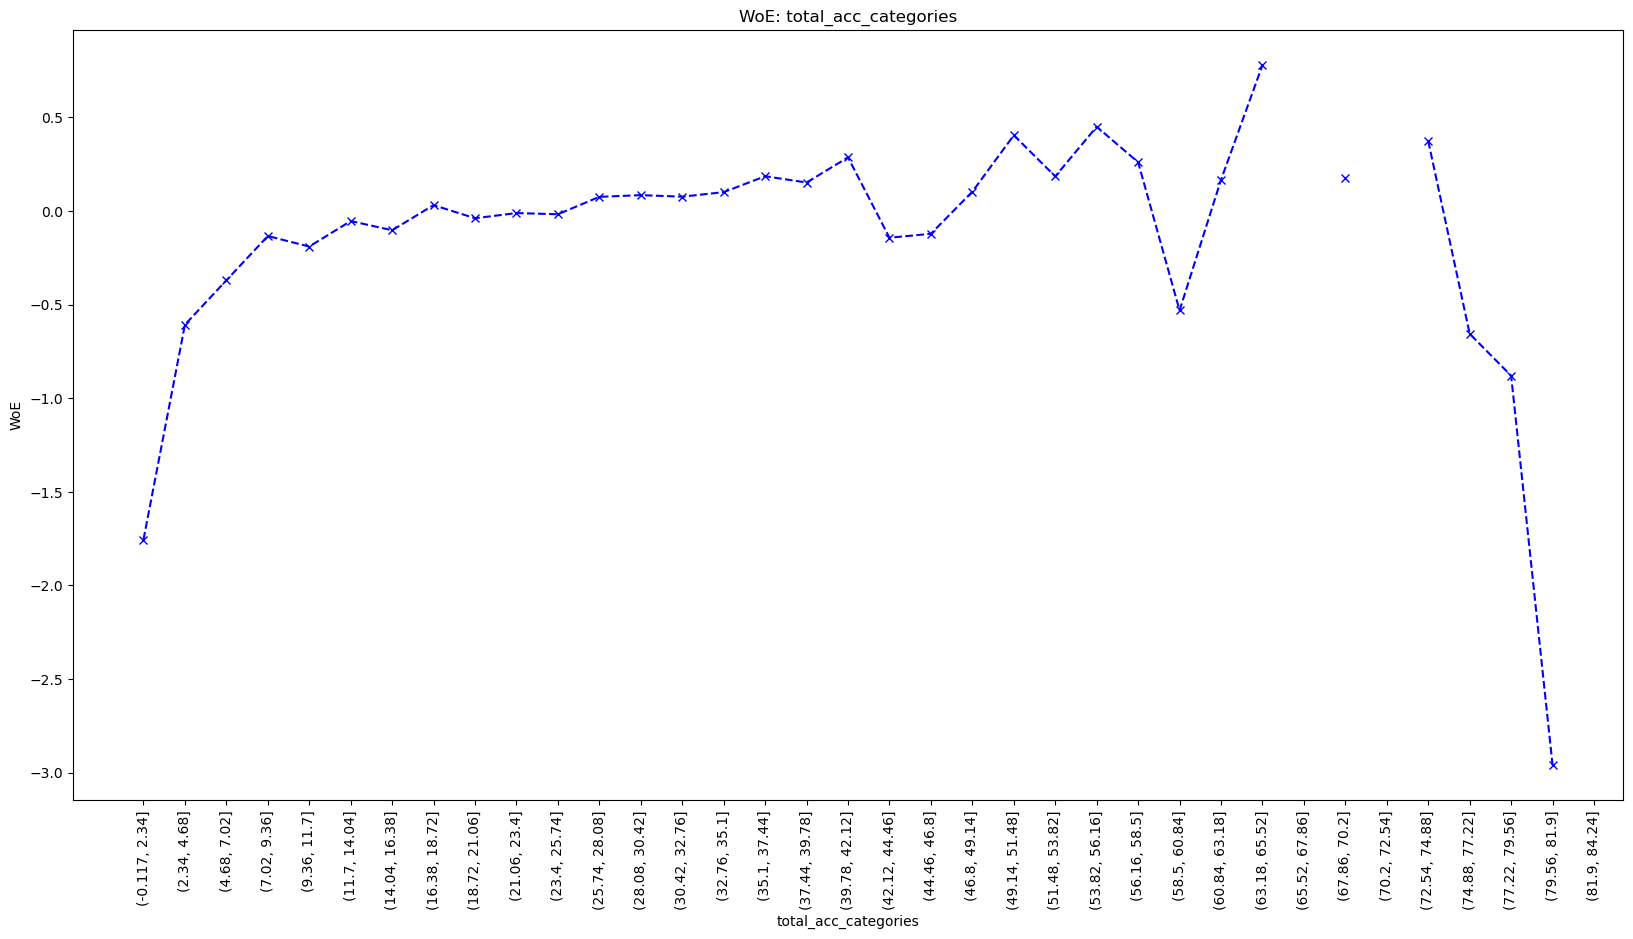

In [595]:
graph_WoE(df)

In [596]:
# Grouping

In [597]:
independent_training['total_acc<=6'] = np.where(independent_training['total_acc'] <= 6,1,0)
independent_training['total_acc_6_22'] = np.where((independent_training['total_acc'] > 6) & (independent_training['total_acc'] <= 22),1,0)
independent_training['total_acc_22_50'] = np.where((independent_training['total_acc'] > 22) & (independent_training['total_acc'] <= 50),1,0)
independent_training['total_acc>50'] = np.where(independent_training['total_acc'] > 50,1,0)

In [598]:
# Processing dti ( debt to income ratio)

In [599]:
independent_training['dti'].unique()

array([29.76, 22.44, 27.12, ..., 38.18, 36.16, 35.06])

In [600]:
independent_training['dti_categories'] = pd.cut(independent_training['dti'],50)

In [601]:
 df = WoE_continuous(independent_training,'dti_categories',dependent_training)
df

C:\Users\matia\AppData\Local\Temp\ipykernel_11828\2187752545.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = d.groupby(categorical_variable, as_index=False)["target"].agg(


,dti_categories,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status,WoE,delta_prop_n_good,delta_WoE,VI,sumVI
0,"(-0.04, 0.8]",172,0.883721,0.003689,152.0,20.0,0.003598,0.004564,-0.237880,NaN,NaN,0.000230,0.047905
1,"(0.8, 1.6]",232,0.844828,0.004975,196.0,36.0,0.004639,0.008215,-0.571432,0.001041,0.333553,0.002043,0.047905
2,"(1.6, 2.399]",318,0.886792,0.006820,282.0,36.0,0.006675,0.008215,-0.207640,0.002036,0.363792,0.000320,0.047905
3,"(2.399, 3.199]",385,0.932468,0.008257,359.0,26.0,0.008498,0.005933,0.359198,0.001823,0.566838,0.000921,0.047905
4,"(3.199, 3.999]",564,0.907801,0.012095,512.0,52.0,0.012119,0.011867,0.021053,0.003622,0.338145,0.000005,0.047905
5,"(3.999, 4.799]",631,0.919176,0.013532,580.0,51.0,0.013729,0.011639,0.165174,0.001610,0.144122,0.000345,0.047905
6,"(4.799, 5.599]",765,0.917647,0.016406,702.0,63.0,0.016617,0.014377,0.144771,0.002888,0.020404,0.000324,0.047905
7,"(5.599, 6.398]",845,0.934911,0.018122,790.0,55.0,0.018700,0.012551,0.398672,0.002083,0.253901,0.002451,0.047905
8,"(6.398, 7.198]",973,0.936280,0.020867,911.0,62.0,0.021564,0.014149,0.421380,0.002864,0.022709,0.003124,0.047905
9,"(7.198, 7.998]",1077,0.921077,0.023097,992.0,85.0,0.023481,0.019398,0.191044,0.001917,0.230337,0.000780,0.047905


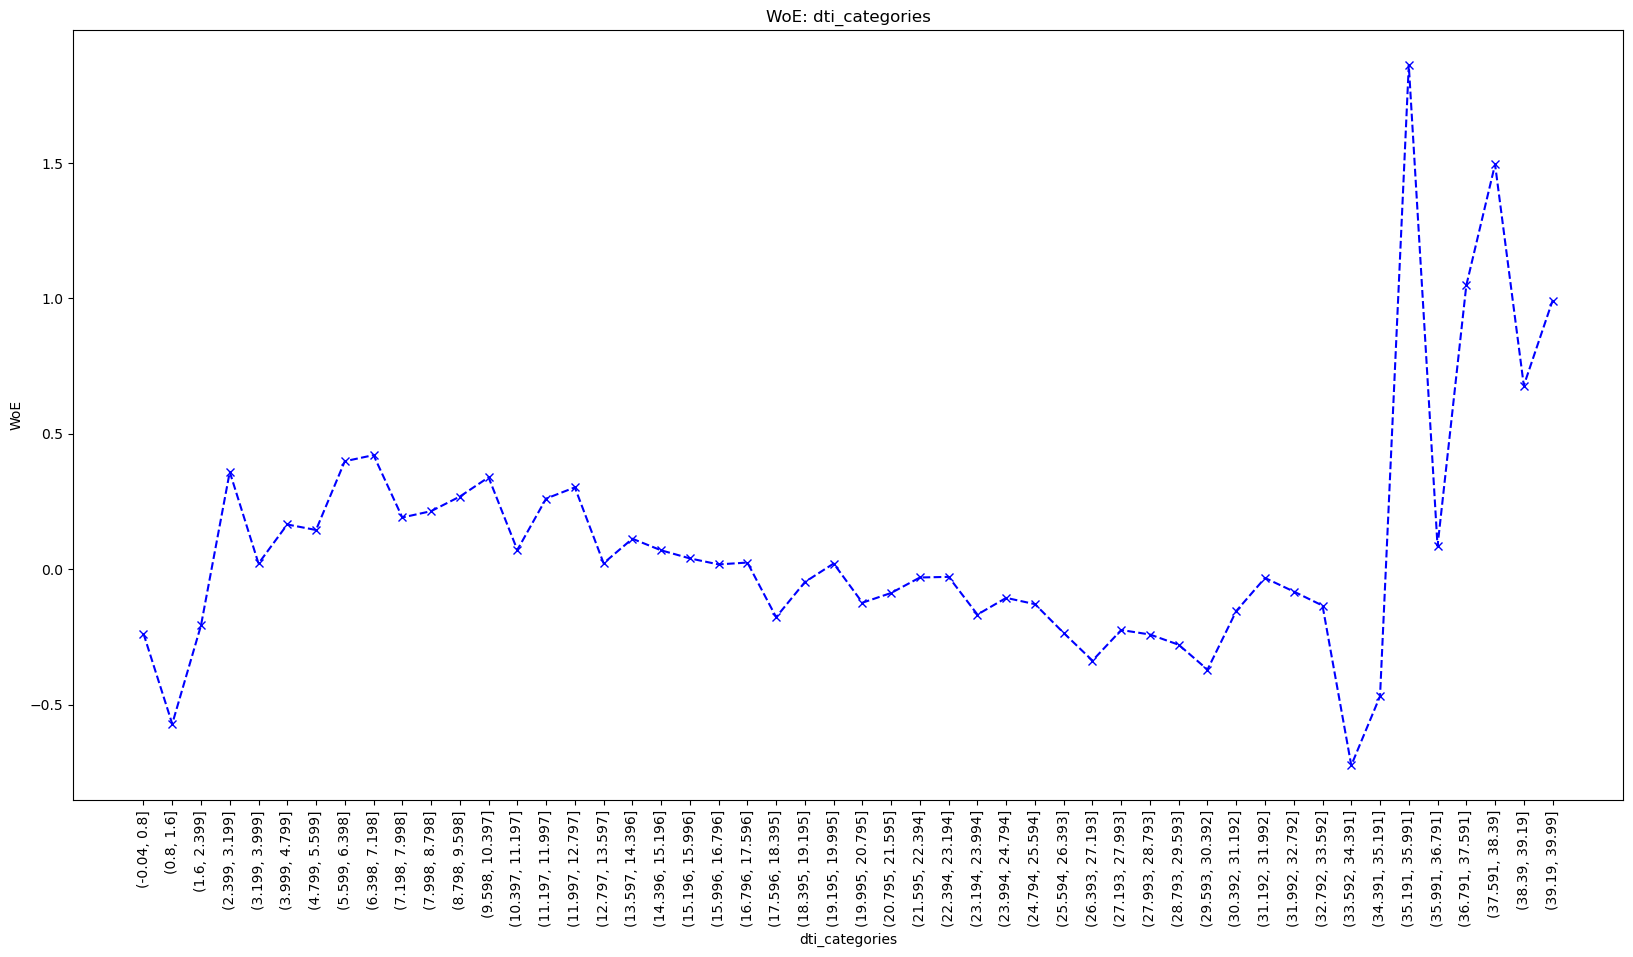

In [602]:
graph_WoE(df)

In [603]:
# Grouping

In [604]:
independent_training['dti<=3.2'] = np.where(independent_training['dti'] <= 3.2,1,0)
independent_training['dti_3.2_8.8'] = np.where((independent_training['dti'] > 3.2) & (independent_training['dti'] <= 8.8),1,0)
independent_training['dti_8.8_10.4'] = np.where((independent_training['dti'] > 8.8) & (independent_training['dti'] <= 10.4),1,0)
independent_training['dti_10.4_13.6'] = np.where((independent_training['dti'] > 10.4) & (independent_training['dti'] <= 13.6),1,0)
independent_training['dti_13.6_16.0'] = np.where((independent_training['dti'] > 13.6) & (independent_training['dti'] <= 16.0),1,0)
independent_training['dti_16.0_16.7'] = np.where((independent_training['dti'] > 16.0) & (independent_training['dti'] <= 16.7),1,0)
independent_training['dti_19.9_20.8'] = np.where((independent_training['dti'] > 19.9) & (independent_training['dti'] <= 20.8),1,0)
independent_training['dti_20.8_23.2'] = np.where((independent_training['dti'] > 20.8) & (independent_training['dti'] <= 23.2),1,0)
independent_training['dti_23.2_35.2'] = np.where((independent_training['dti'] > 23.2) & (independent_training['dti'] <= 35.2),1,0)
independent_training['dti>35.2'] = np.where(independent_training['dti'] > 35.2,1,0)

In [605]:
# Processing mths_since_last_record

In [606]:
independent_training['mths_since_last_record'].unique()

array([ nan,  67.,   0.,  21.,  58.,  62.,  16.,  48., 118.,  87.,  71.,
        75., 104.,  59.,  65.,  35.,  89.,  61., 116.,  36., 112.,  51.,
        50., 102.,  49.,  85.,  72.,  63.,  84.,  79.,  22., 111., 106.,
        60., 105., 107.,  12., 119.,  99.,  55.,  37., 103.,  81.,  30.,
        52.,  40.,  68.,  56.,  80., 114.,  95.,   1.,  86.,  28.,  54.,
        57., 110., 113.,  82., 109.,  64., 117.,  91.,  34.,  24.,   9.,
       100., 108.,  39.,  76.,  53., 101.,  74.,  47.,  25.,  78.,  70.,
        32.,  94.,  31.,  83.,  96.,  93.,  45.,  14.,  44.,  92.,  88.,
        23.,  33.,  19.,  90.,  69.,  42.,  26.,  20.,  46.,  73.,  97.,
        18., 115.,  38.,  98.,  10.,  15.,  77.,  66.,  43.,  41.,  11.,
        29.,  27.,   8.,   7.,  13.,   6.,   5.,   3.,   4.,  17.,   2.])

In [607]:
# Creating a temporary dataframe for numerical values


In [608]:
df_temp = independent_training[pd.notnull(independent_training['mths_since_last_record'])]

In [609]:
df_temp['mths_since_last_record_categories'] = pd.cut(df_temp['mths_since_last_record'],50)

C:\Users\matia\AppData\Local\Temp\ipykernel_11828\1844352472.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['mths_since_last_record_categories'] = pd.cut(df_temp['mths_since_last_record'],50)


In [610]:
df = WoE_continuous(df_temp,'mths_since_last_record_categories',dependent_training)
df

C:\Users\matia\AppData\Local\Temp\ipykernel_11828\2187752545.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = d.groupby(categorical_variable, as_index=False)["target"].agg(


,mths_since_last_record_categories,observations,prop_good_status,prop_observations,n_good_status,n_bad_status,total_prop_good_status,total_prop_bad_status,WoE,delta_prop_n_good,delta_WoE,VI,sumVI
0,"(-0.119, 2.38]",150,0.746667,0.023471,112.0,38.0,0.019387,0.061889,-1.160732,NaN,NaN,0.049333,0.211774
1,"(2.38, 4.76]",10,0.800000,0.001565,8.0,2.0,0.001385,0.003257,-0.855351,0.018002,0.305382,0.001602,0.211774
2,"(4.76, 7.14]",20,1.000000,0.003129,20.0,0.0,0.003462,0.000000,NaN,0.002077,NaN,NaN,0.211774
3,"(7.14, 9.52]",18,0.833333,0.002816,15.0,3.0,0.002597,0.004886,-0.632207,0.000866,NaN,0.001447,0.211774
4,"(9.52, 11.9]",16,1.000000,0.002504,16.0,0.0,0.002770,0.000000,NaN,0.000173,NaN,NaN,0.211774
5,"(11.9, 14.28]",29,0.965517,0.004538,28.0,1.0,0.004847,0.001629,1.090560,0.002077,NaN,0.003510,0.211774
6,"(14.28, 16.66]",28,0.857143,0.004381,24.0,4.0,0.004154,0.006515,-0.449885,0.000692,1.540445,0.001062,0.211774
7,"(16.66, 19.04]",46,0.934783,0.007198,43.0,3.0,0.007443,0.004886,0.420943,0.003289,0.870828,0.001076,0.211774
8,"(19.04, 21.42]",30,0.866667,0.004694,26.0,4.0,0.004501,0.006515,-0.369843,0.002943,0.790786,0.000745,0.211774
9,"(21.42, 23.8]",33,0.909091,0.005164,30.0,3.0,0.005193,0.004886,0.060940,0.000692,0.430783,0.000019,0.211774


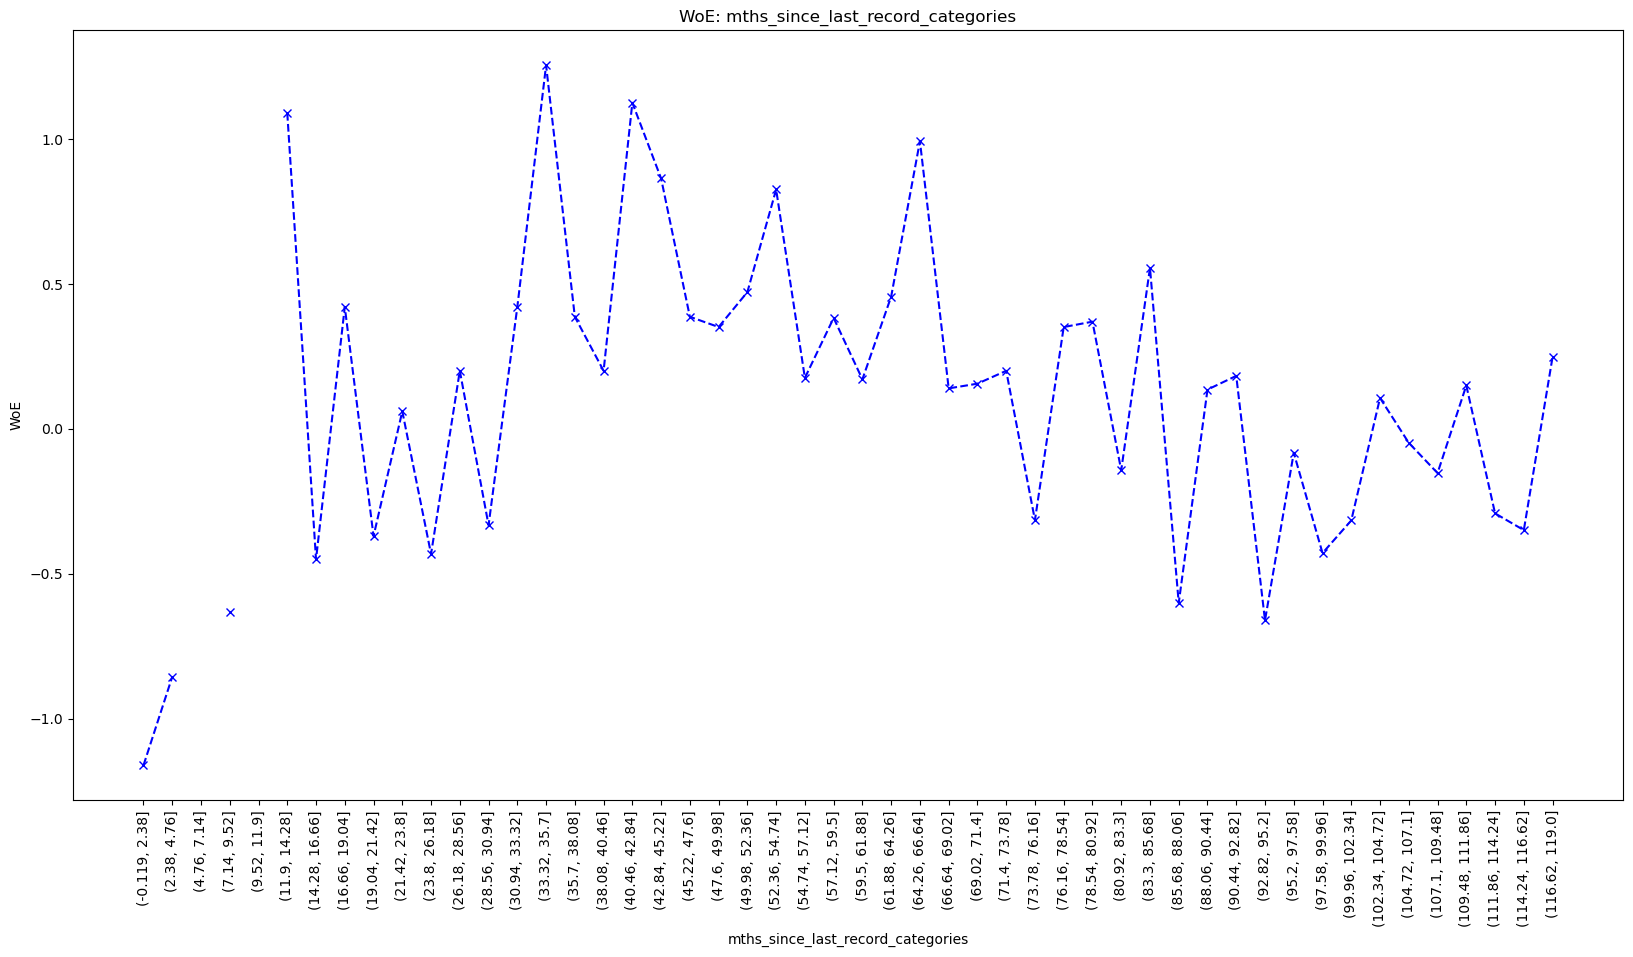

In [611]:
graph_WoE(df)

In [612]:
independent_training['mths_since_last_record_null'] = np.where((independent_training['mths_since_last_record'].isnull()),1,0)
independent_training['mths_since_last_record_0_3'] = np.where((independent_training['mths_since_last_record'] > 0) & (independent_training['mths_since_last_record'] <= 3),1,0)
independent_training['mths_since_last_record_3_21'] = np.where((independent_training['mths_since_last_record'] > 3) & (independent_training['mths_since_last_record'] <= 21),1,0)
independent_training['mths_since_last_record_21_31'] = np.where((independent_training['mths_since_last_record'] > 21) & (independent_training['mths_since_last_record'] <= 31),1,0)
independent_training['mths_since_last_record_31_85'] = np.where((independent_training['mths_since_last_record'] > 31) & (independent_training['mths_since_last_record'] <= 85),1,0)
independent_training['mths_since_last_record>85'] = np.where(independent_training['mths_since_last_record'] > 85,1,0)

In [613]:
# Processing independent_testing

In [614]:
#saved_data_independent_training = independent_training
#saved_data_dependent_training = dependent_training

In [615]:
# after re running the code we can save the dataframes

In [616]:
saved_data_independent_testing = independent_training
saved_data_dependent_testing = dependent_testing

In [617]:
import os
os.makedirs("data/processed", exist_ok=True)

saved_data_independent_training.to_csv('data/processed/independent_training.csv')
saved_data_dependent_training.to_csv('data/processed/dependent_training.csv')
saved_data_independent_testing.to_csv('data/processed/independent_testing.csv')
saved_data_dependent_testing.to_csv('data/processed/dependent_testing.csv')

print("All files saved to data/processed/")

All files saved to data/processed/


## Output

Four CSV files have been saved to `data/processed/`:

| File | Description |
|------|-------------|
| `independent_training.csv` | Training features (WoE encoded) |
| `dependent_training.csv` | Training labels (0=bad, 1=good) |
| `independent_testing.csv` | Test features (WoE encoded) |
| `dependent_testing.csv` | Test labels (0=bad, 1=good) |

These files are used as inputs to `PD_Model.ipynb`.